In [1]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 风格
plt.style.use('seaborn-whitegrid')

# 全局设置
config = {'font.family':'Times New Roman', 'figure.dpi':300, 'figure.figsize':(10,8), 'axes.labelsize':15, 'axes.titlesize':15}
plt.rcParams.update(config)

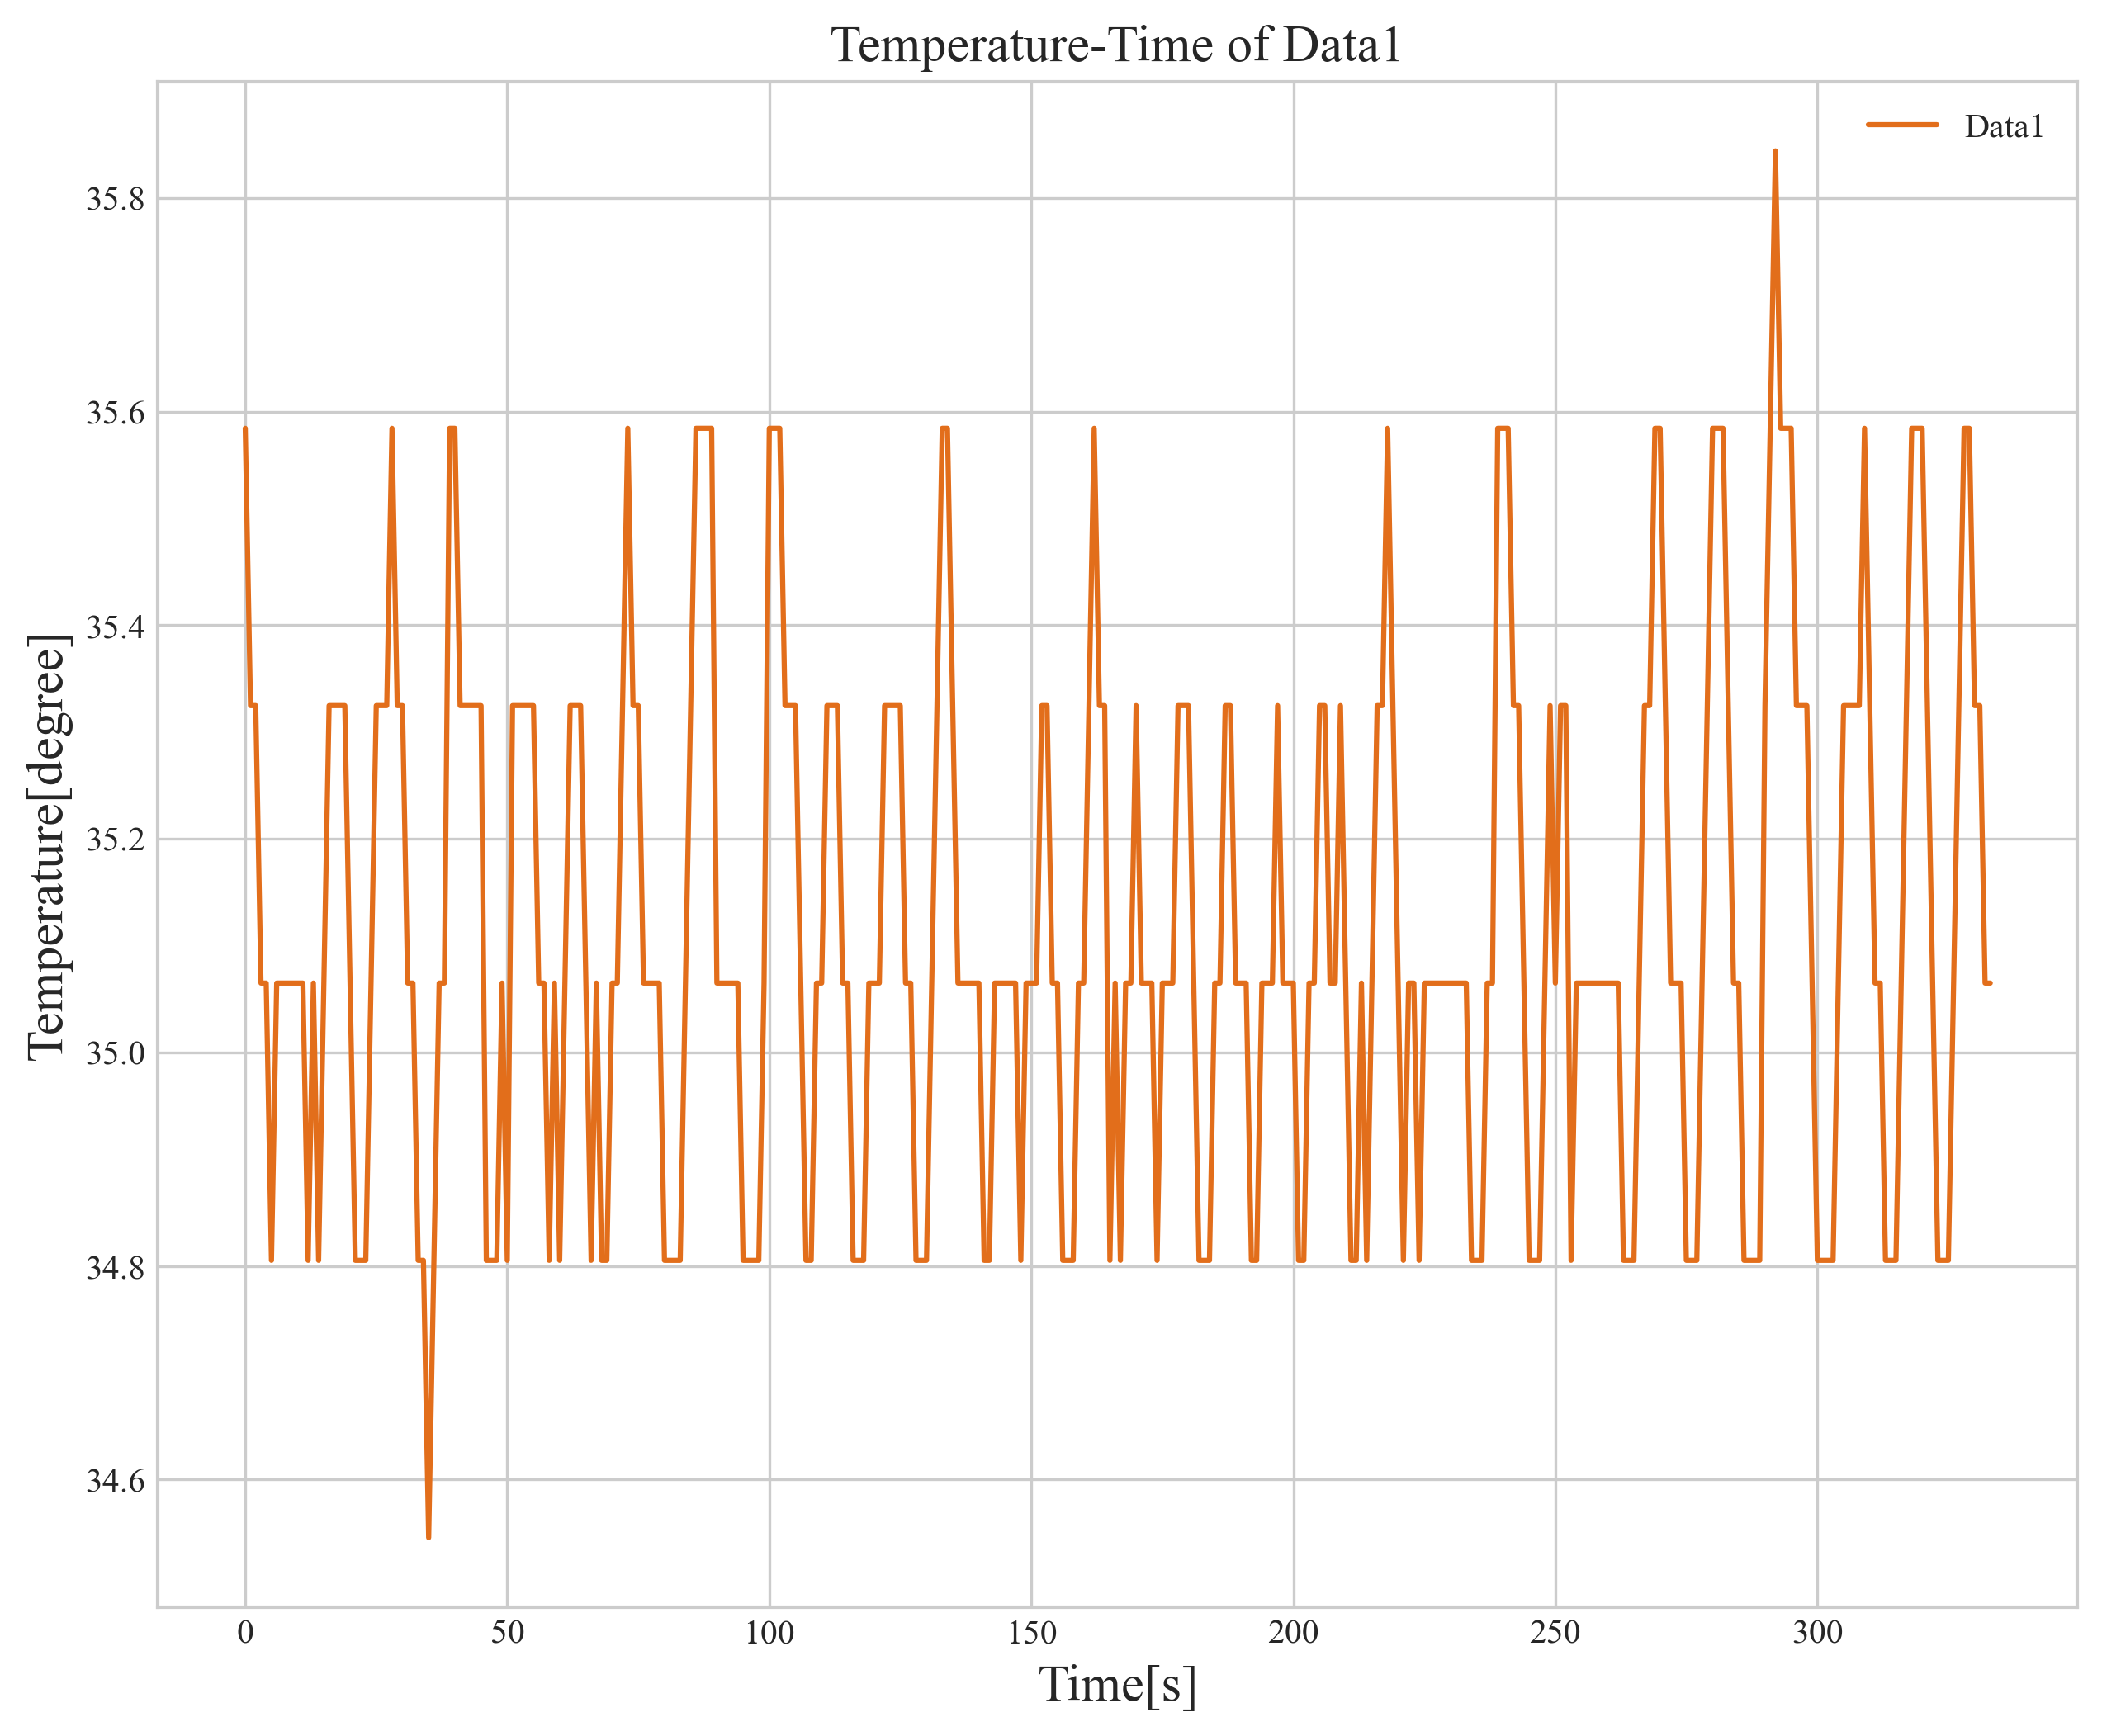

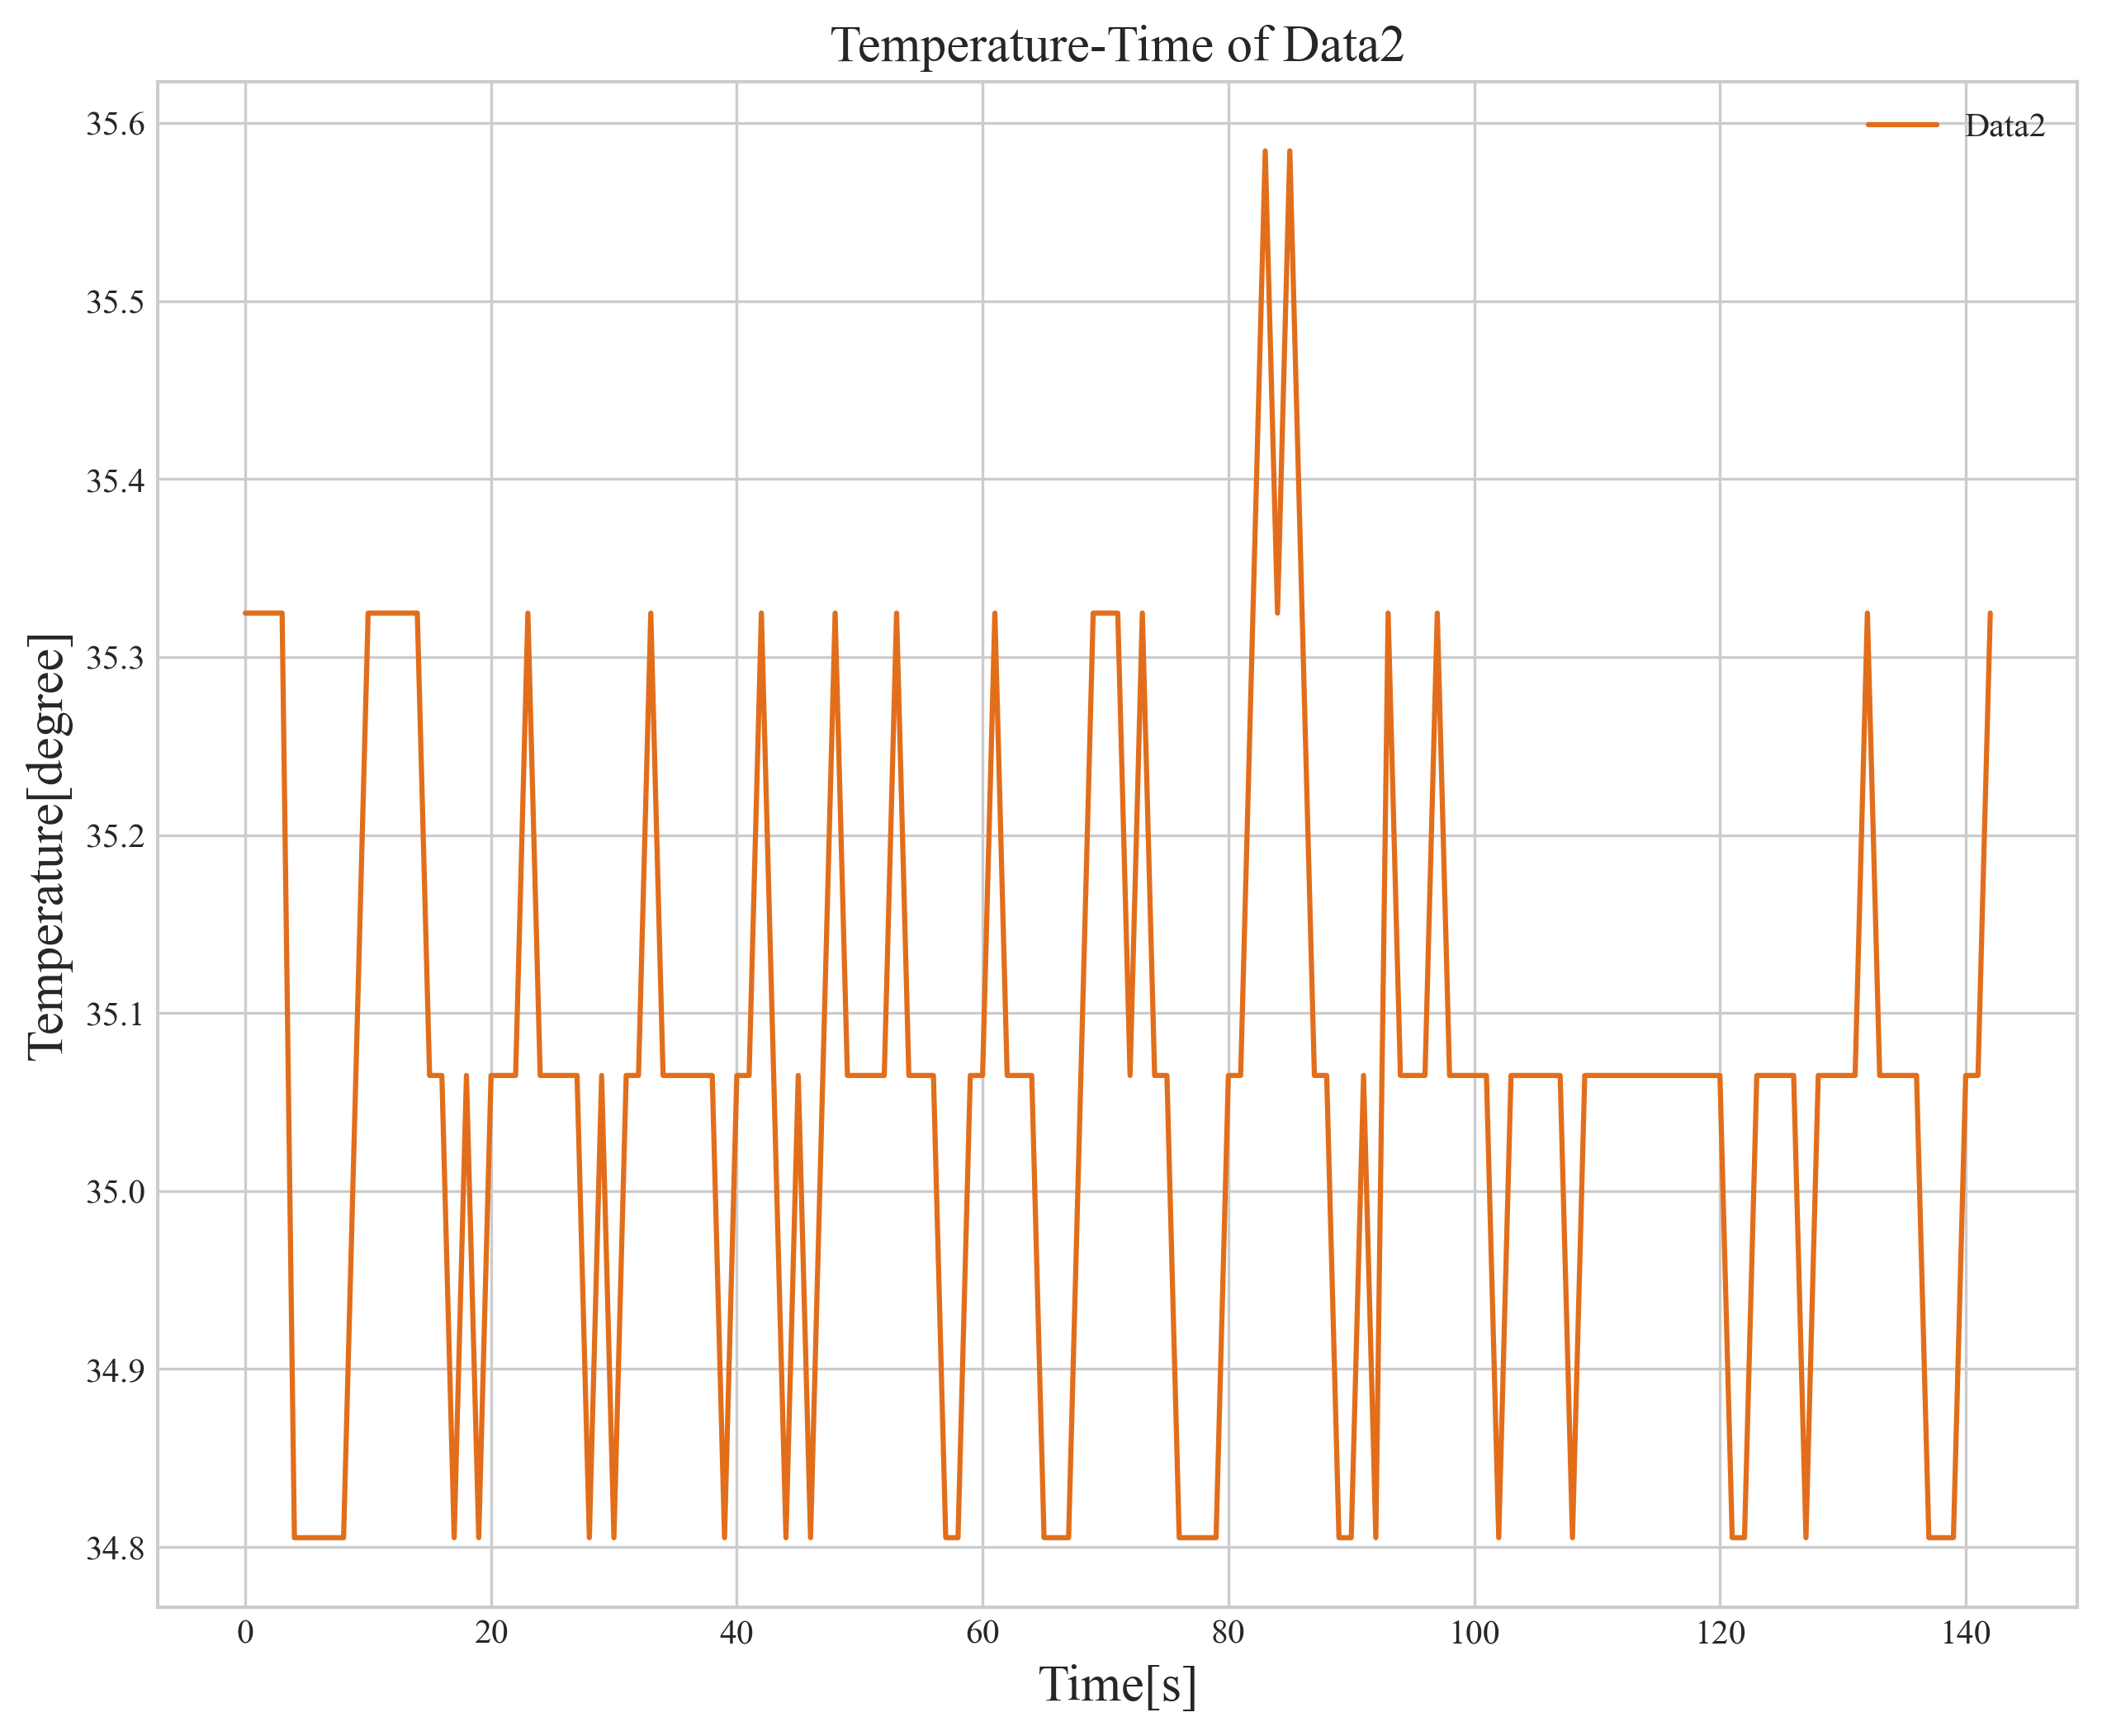

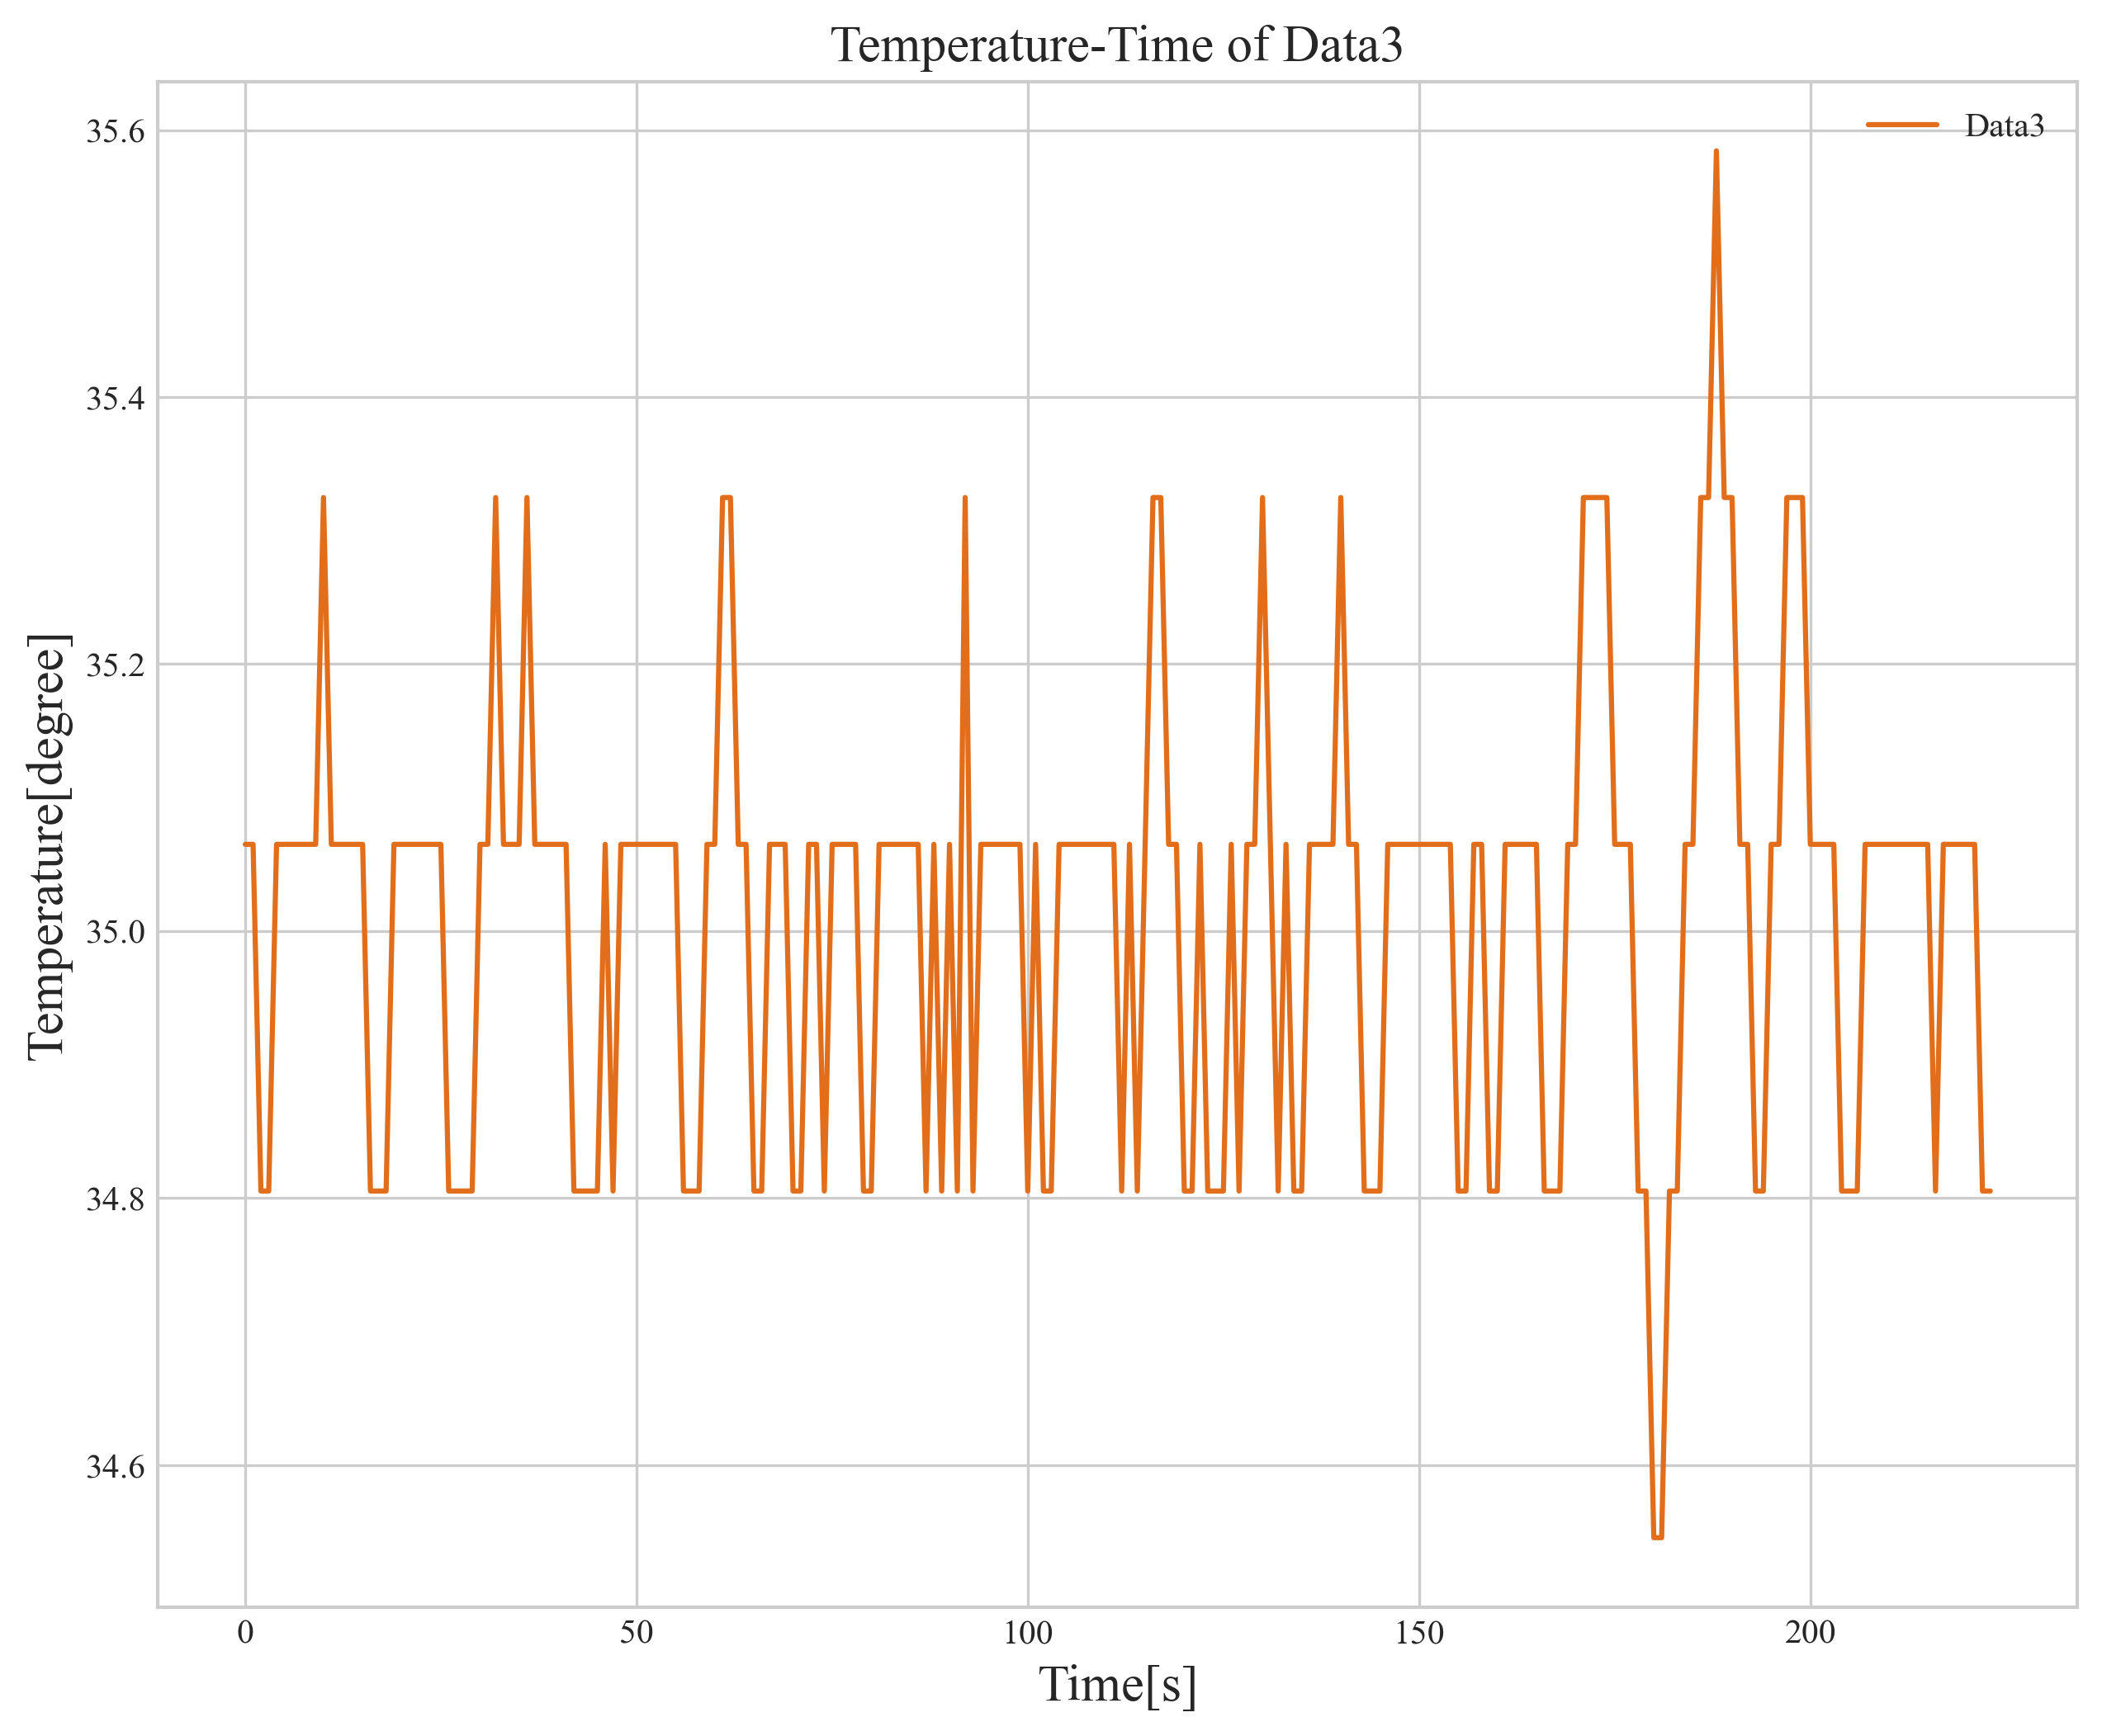

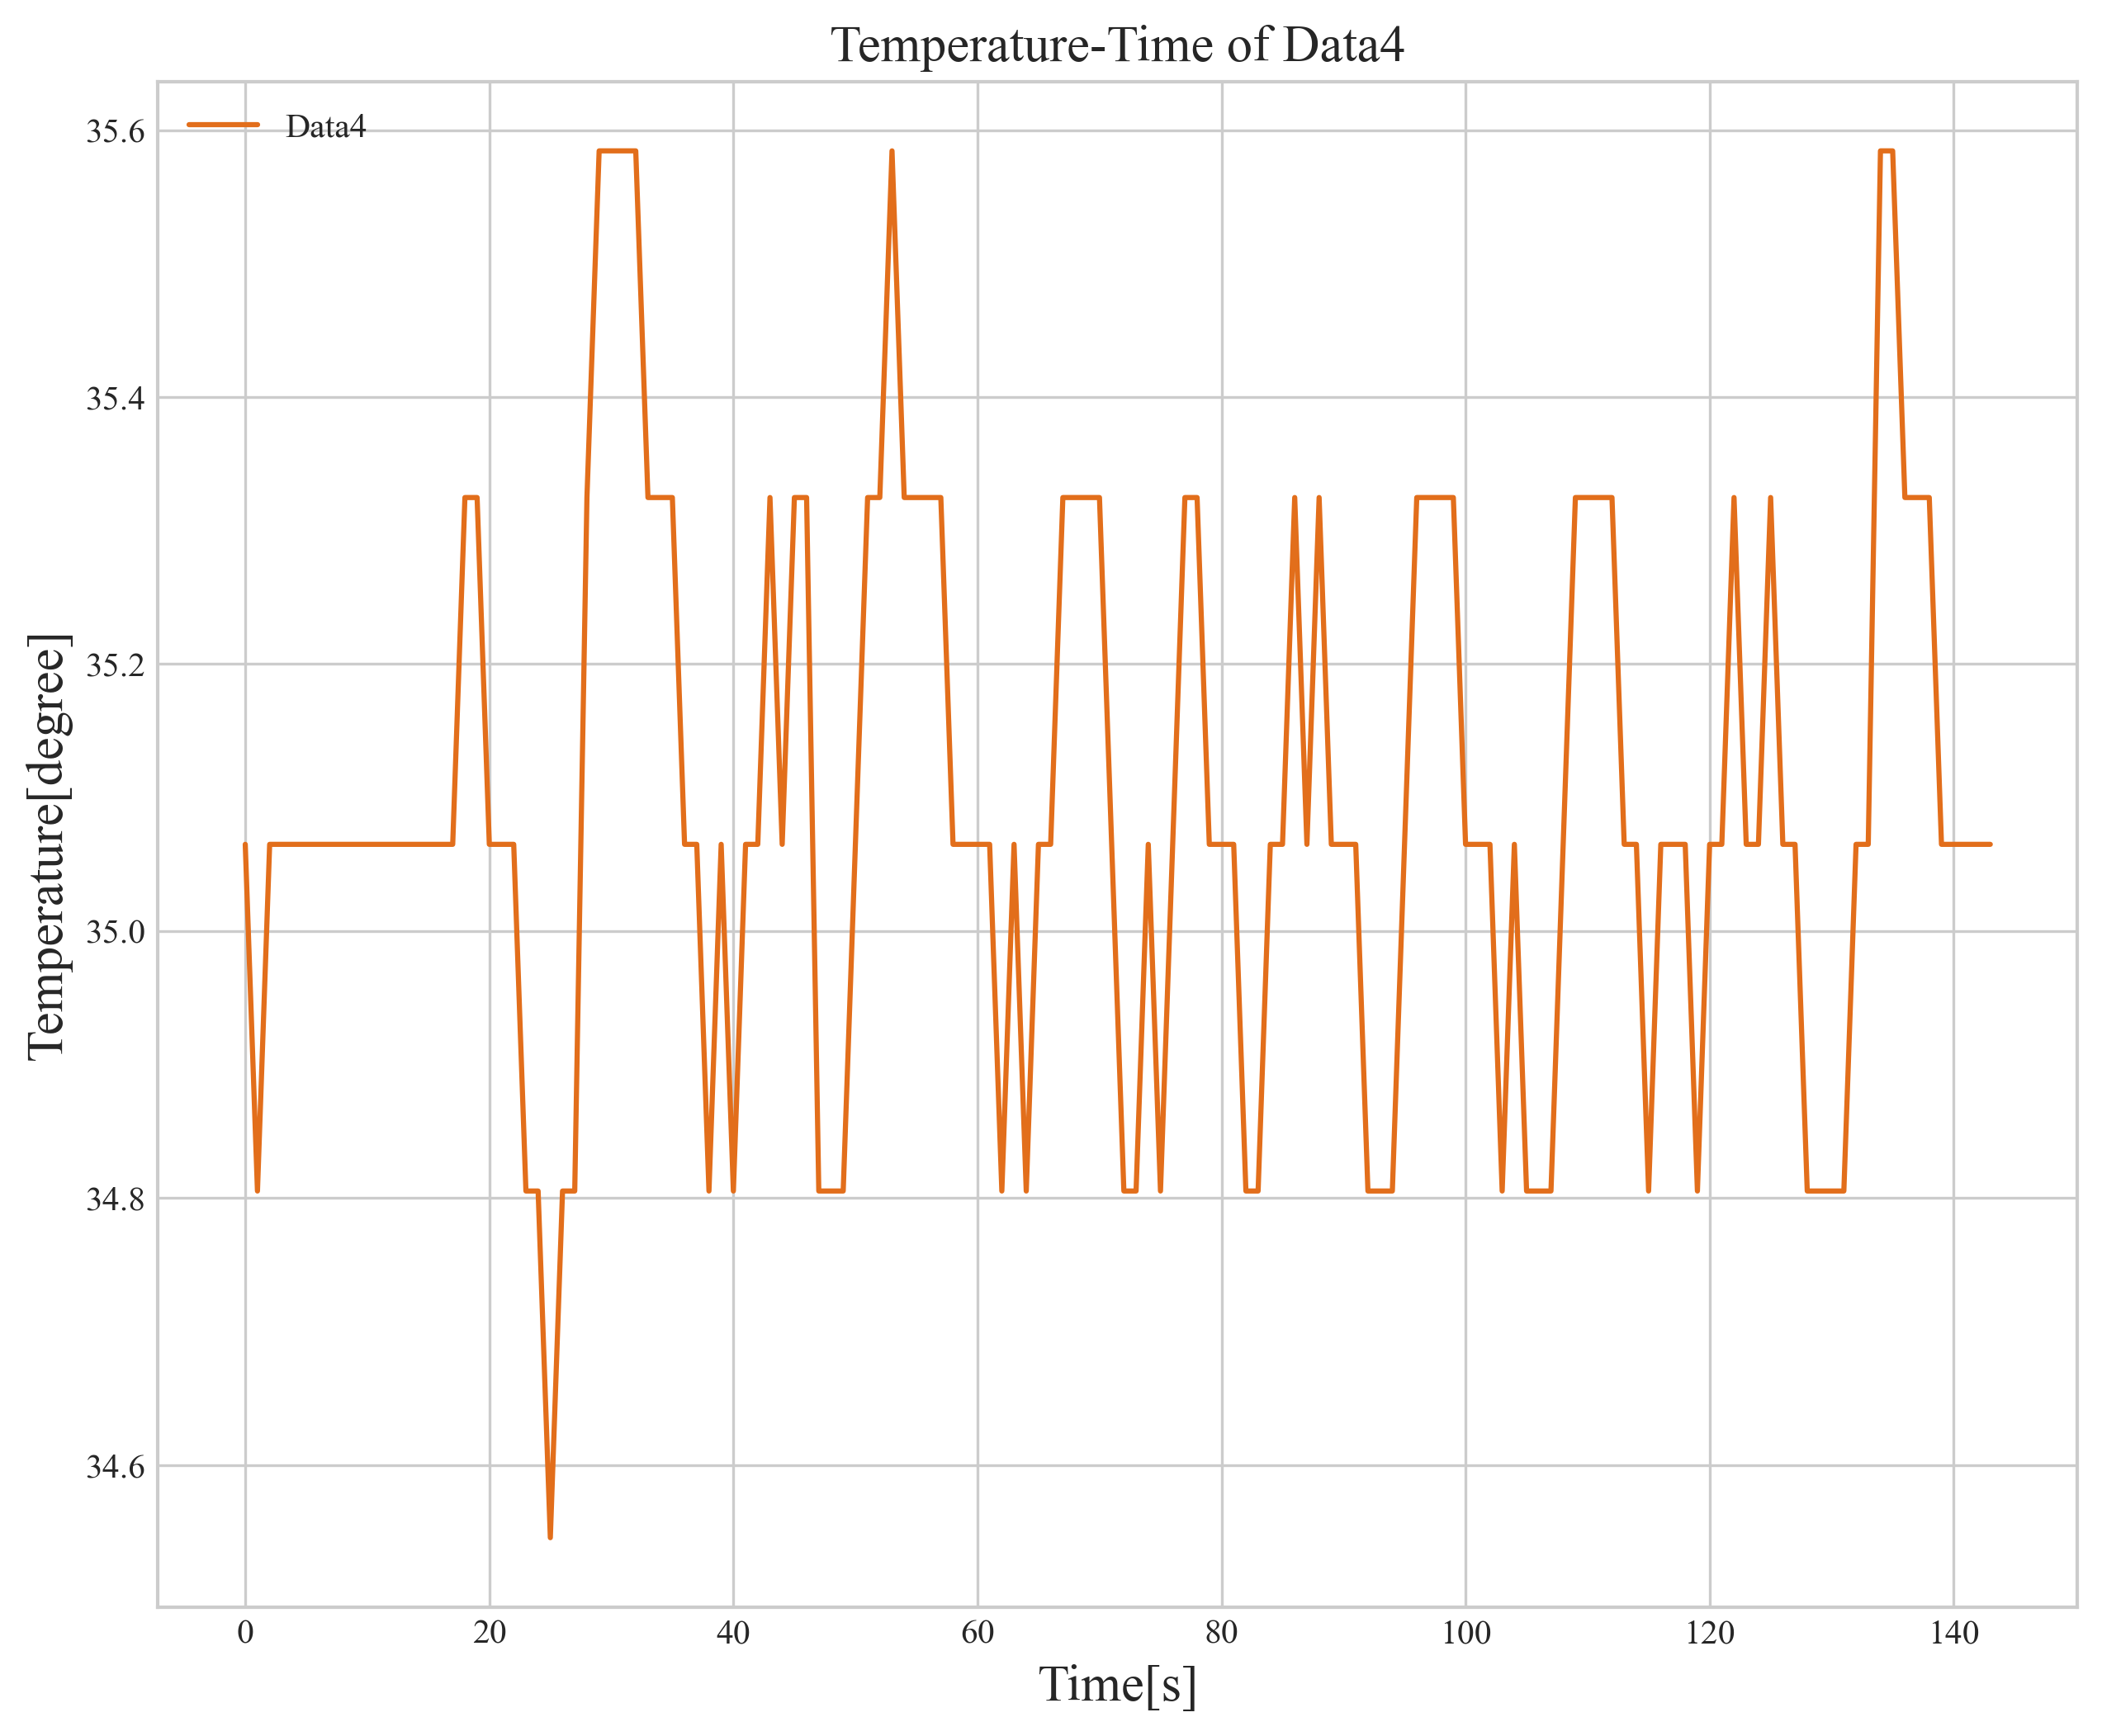

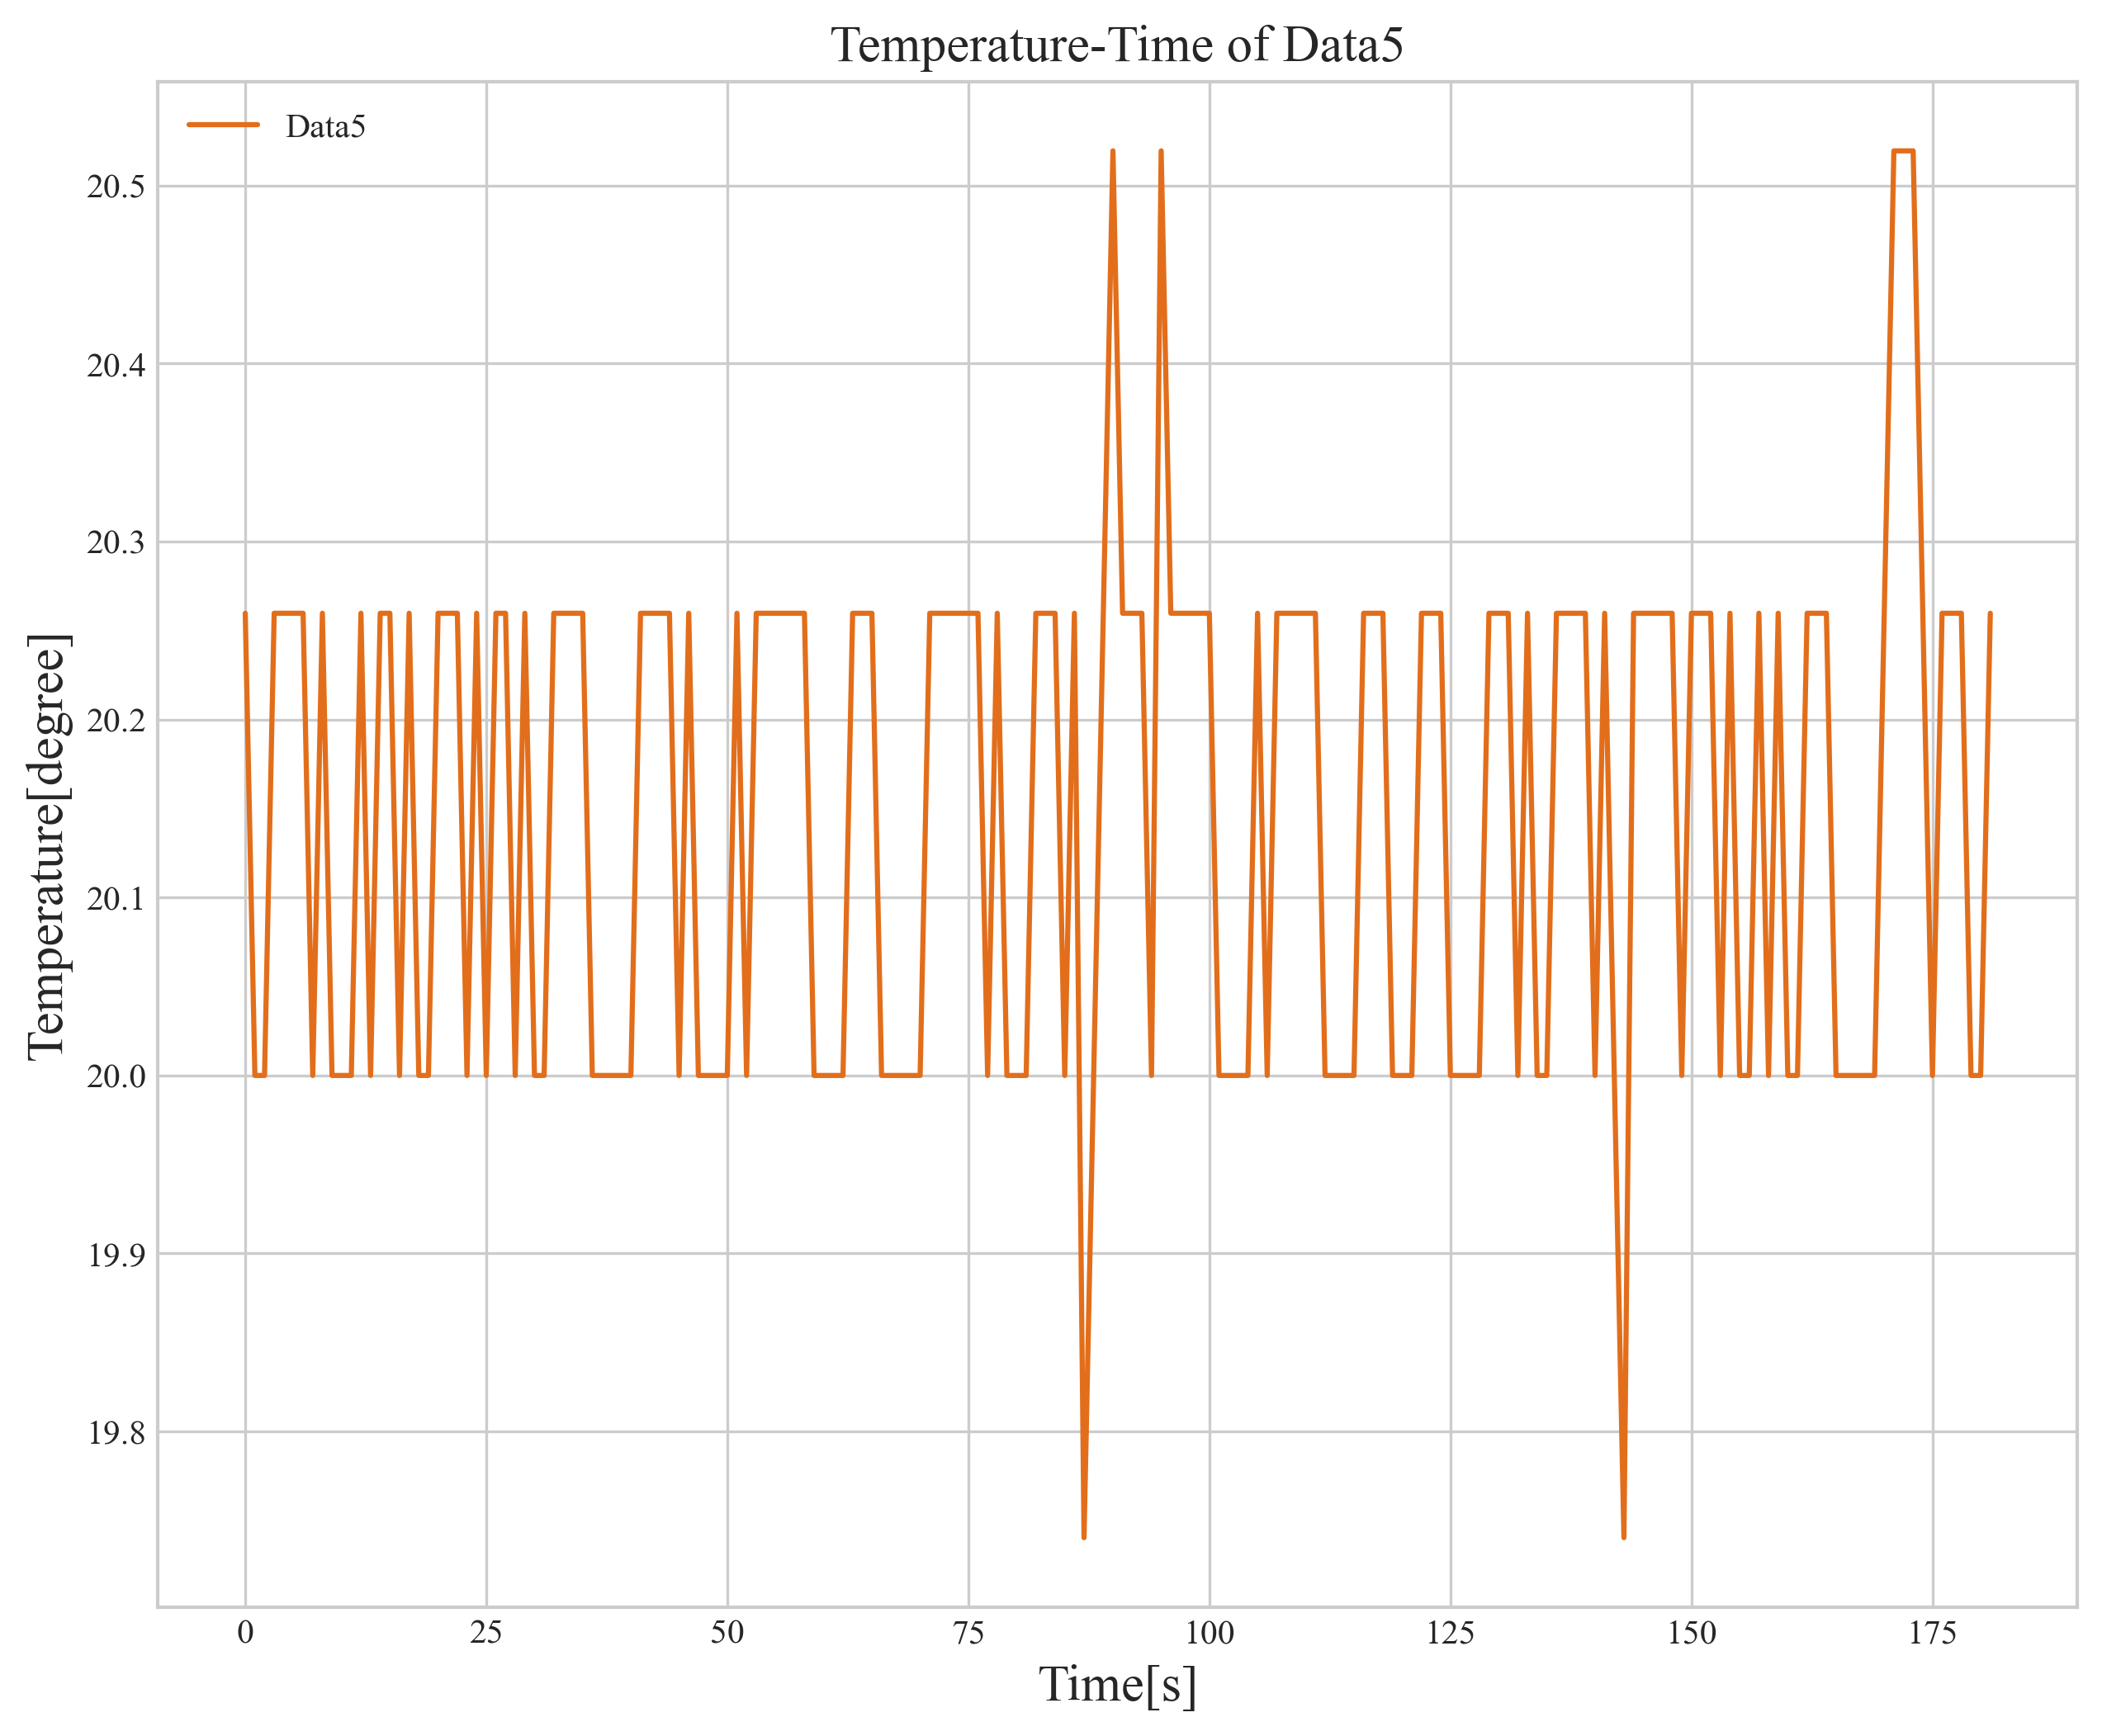

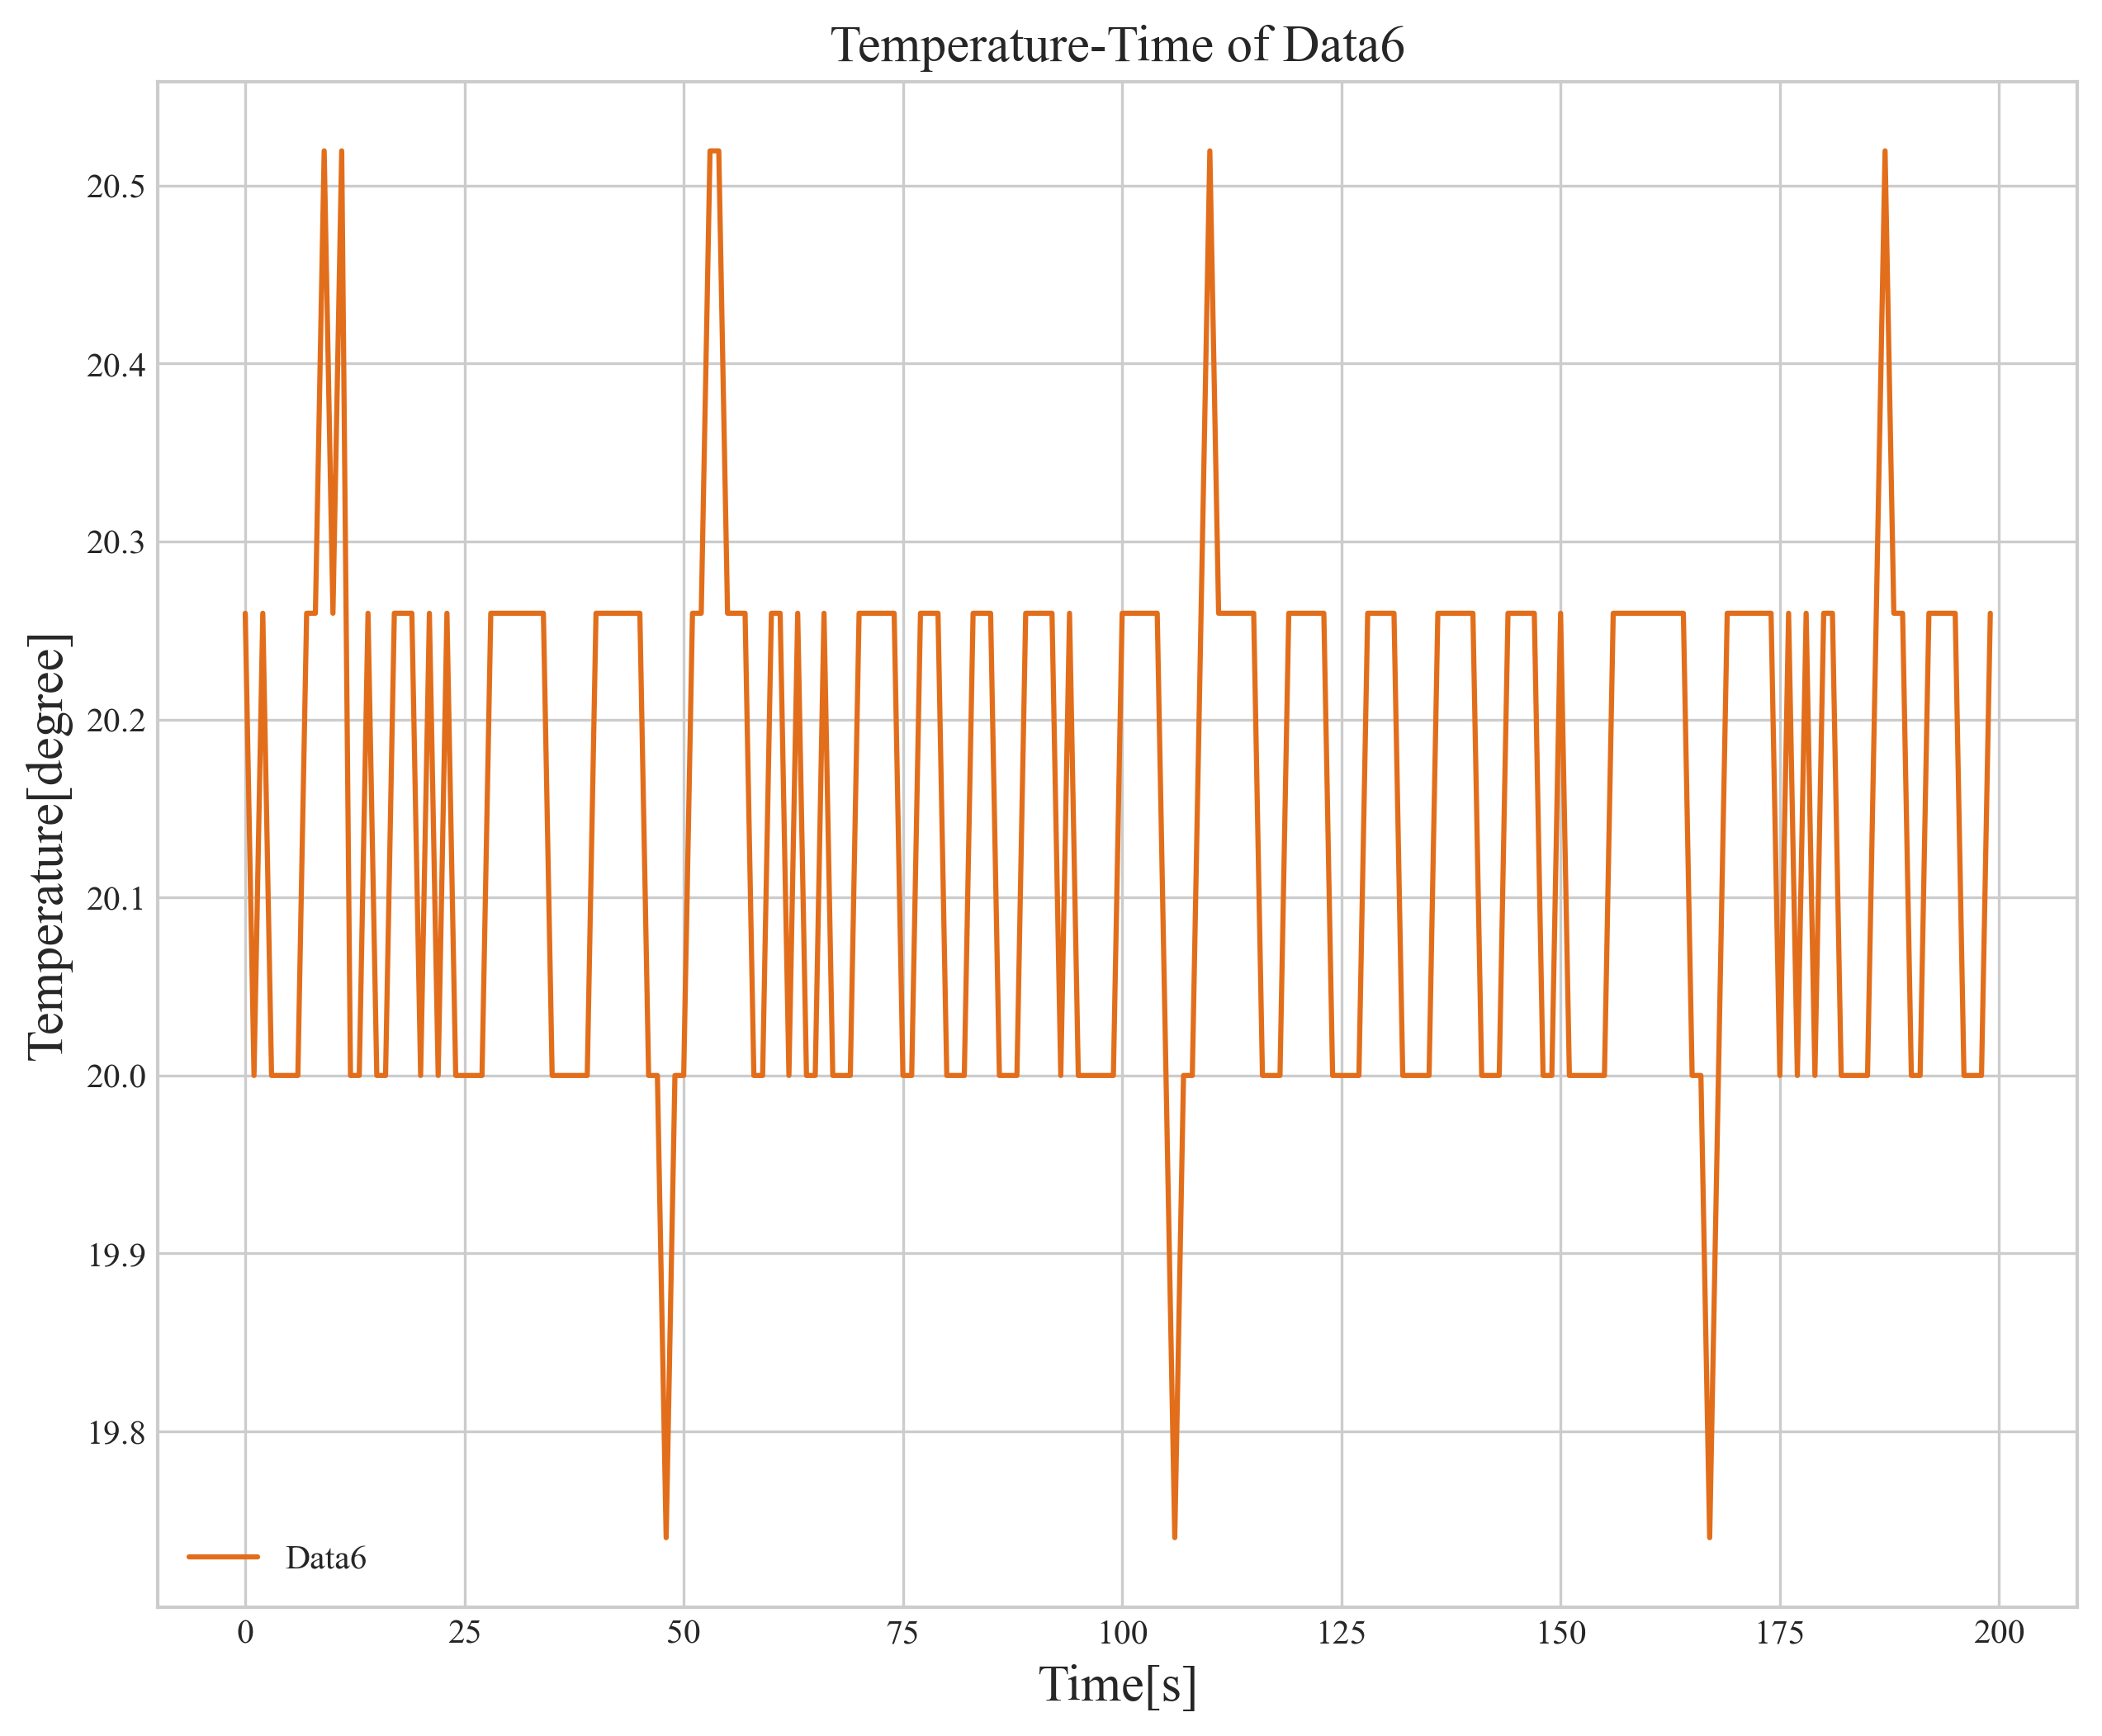

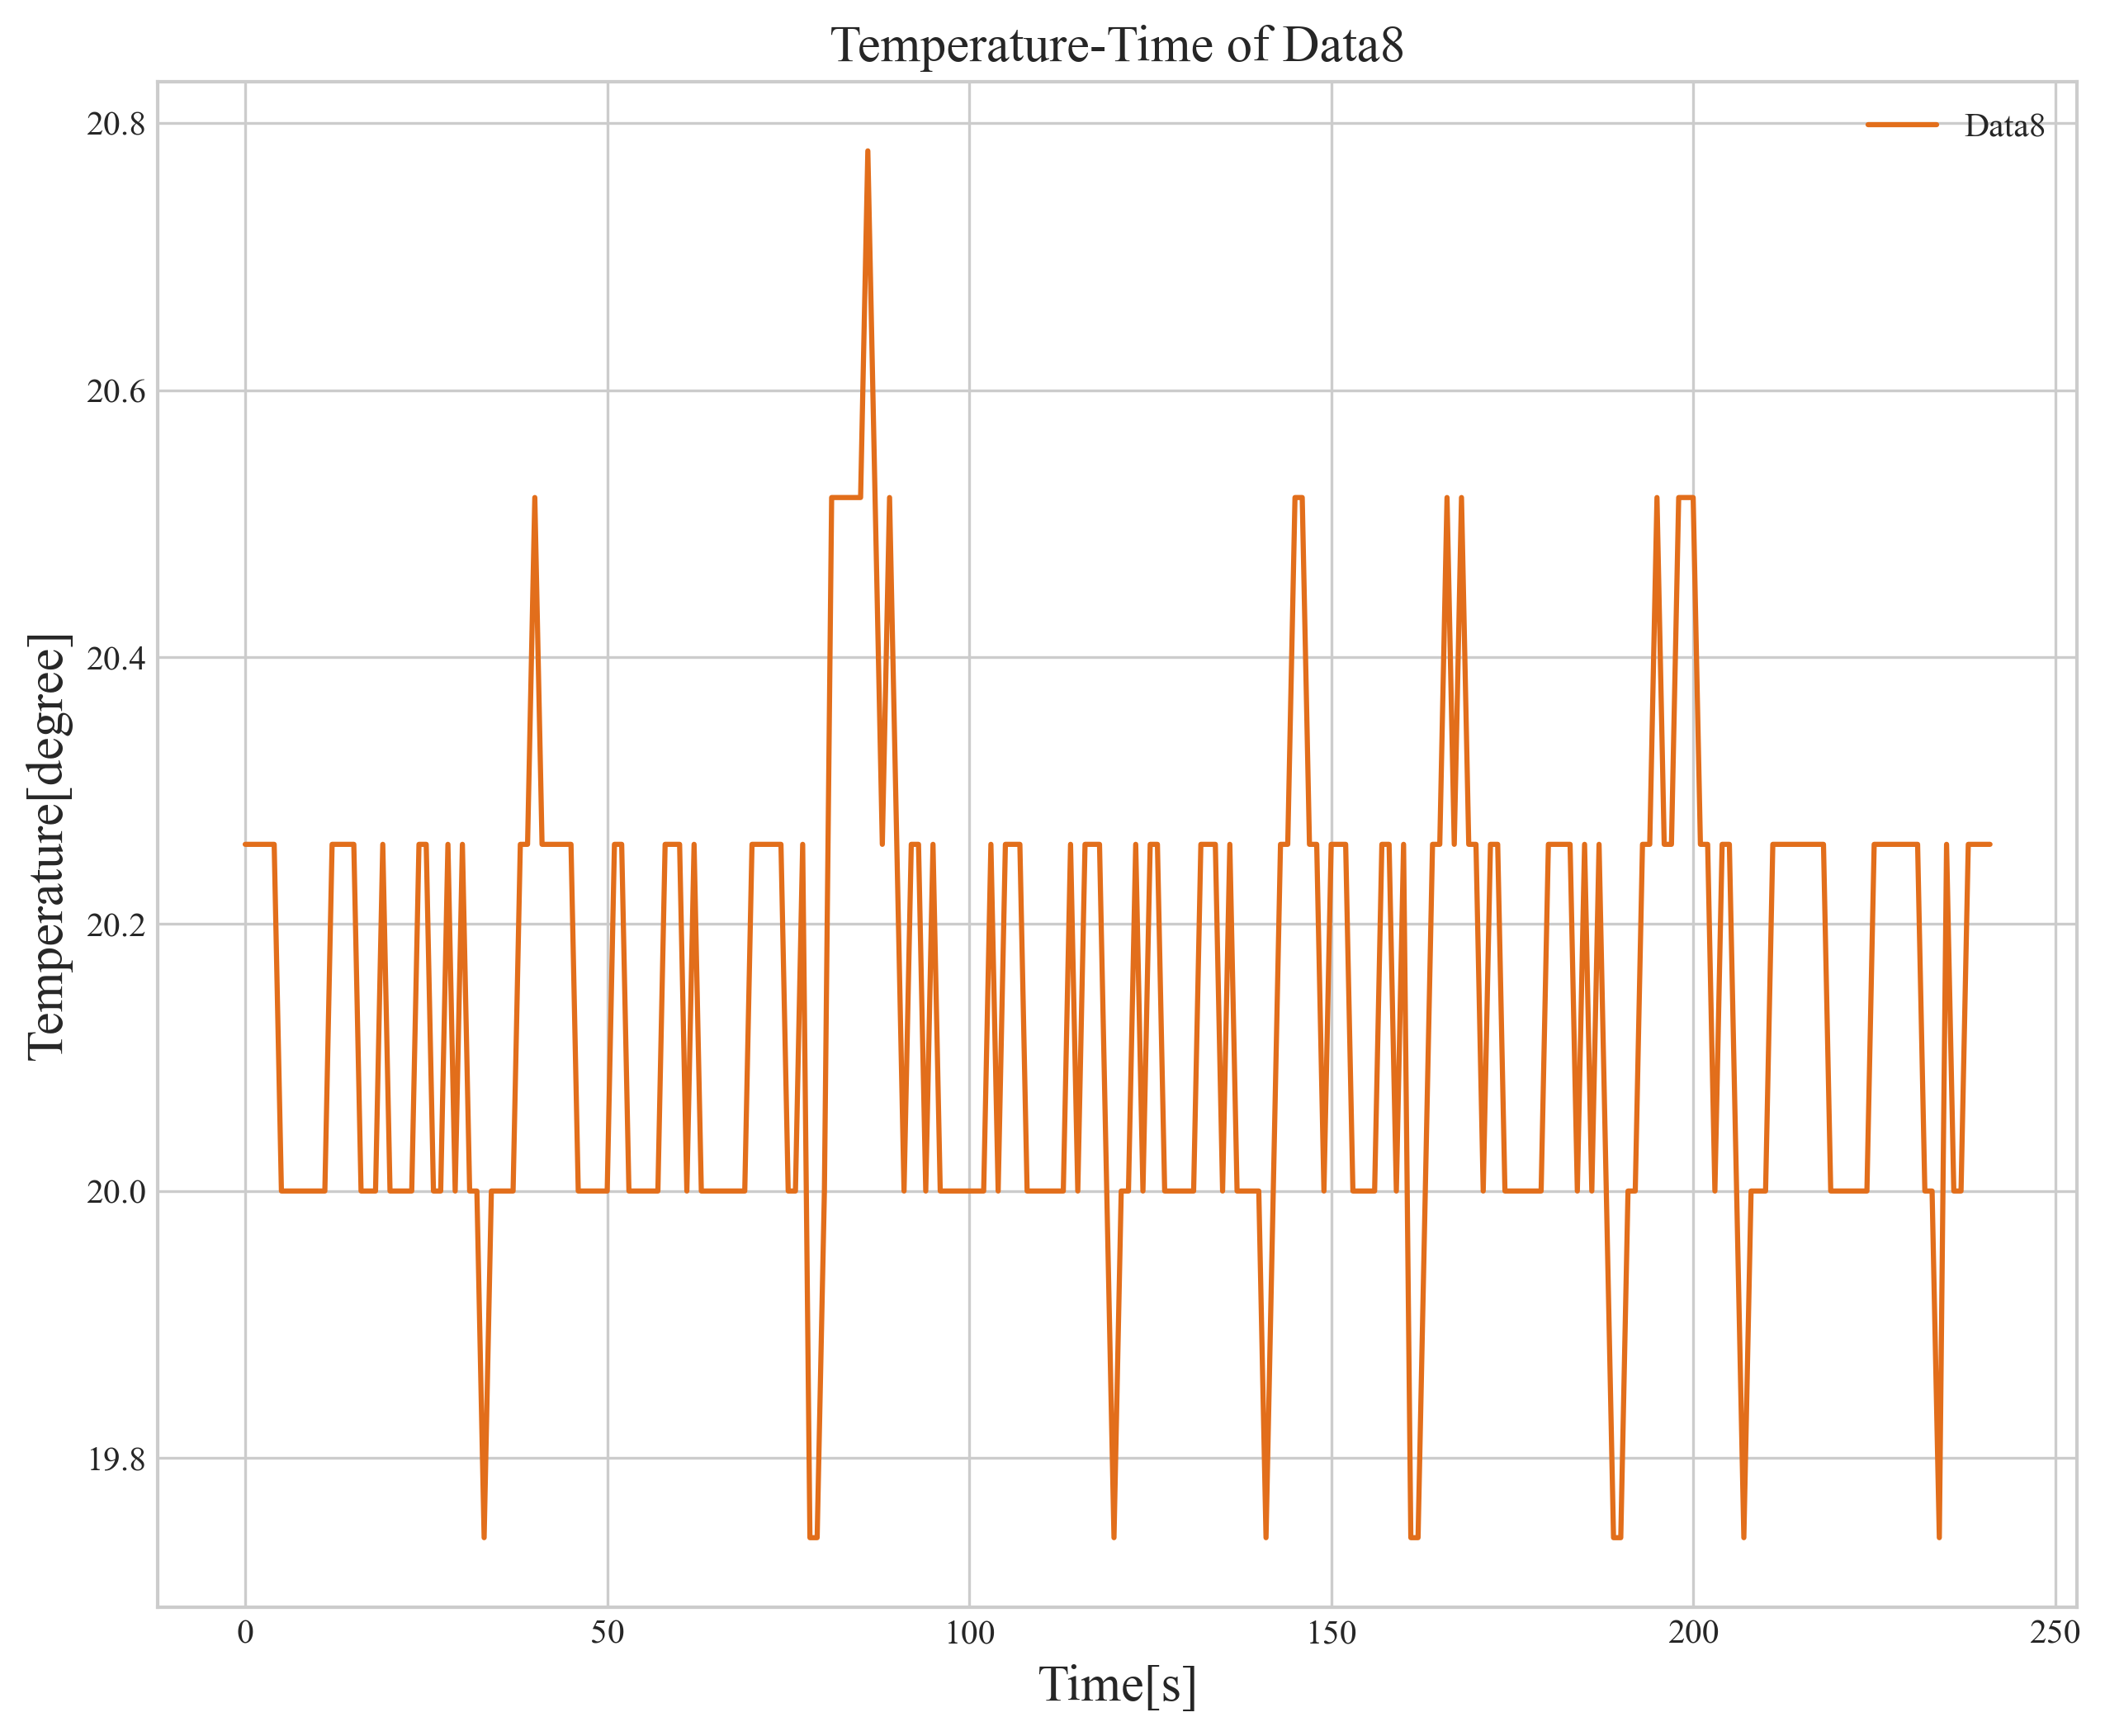

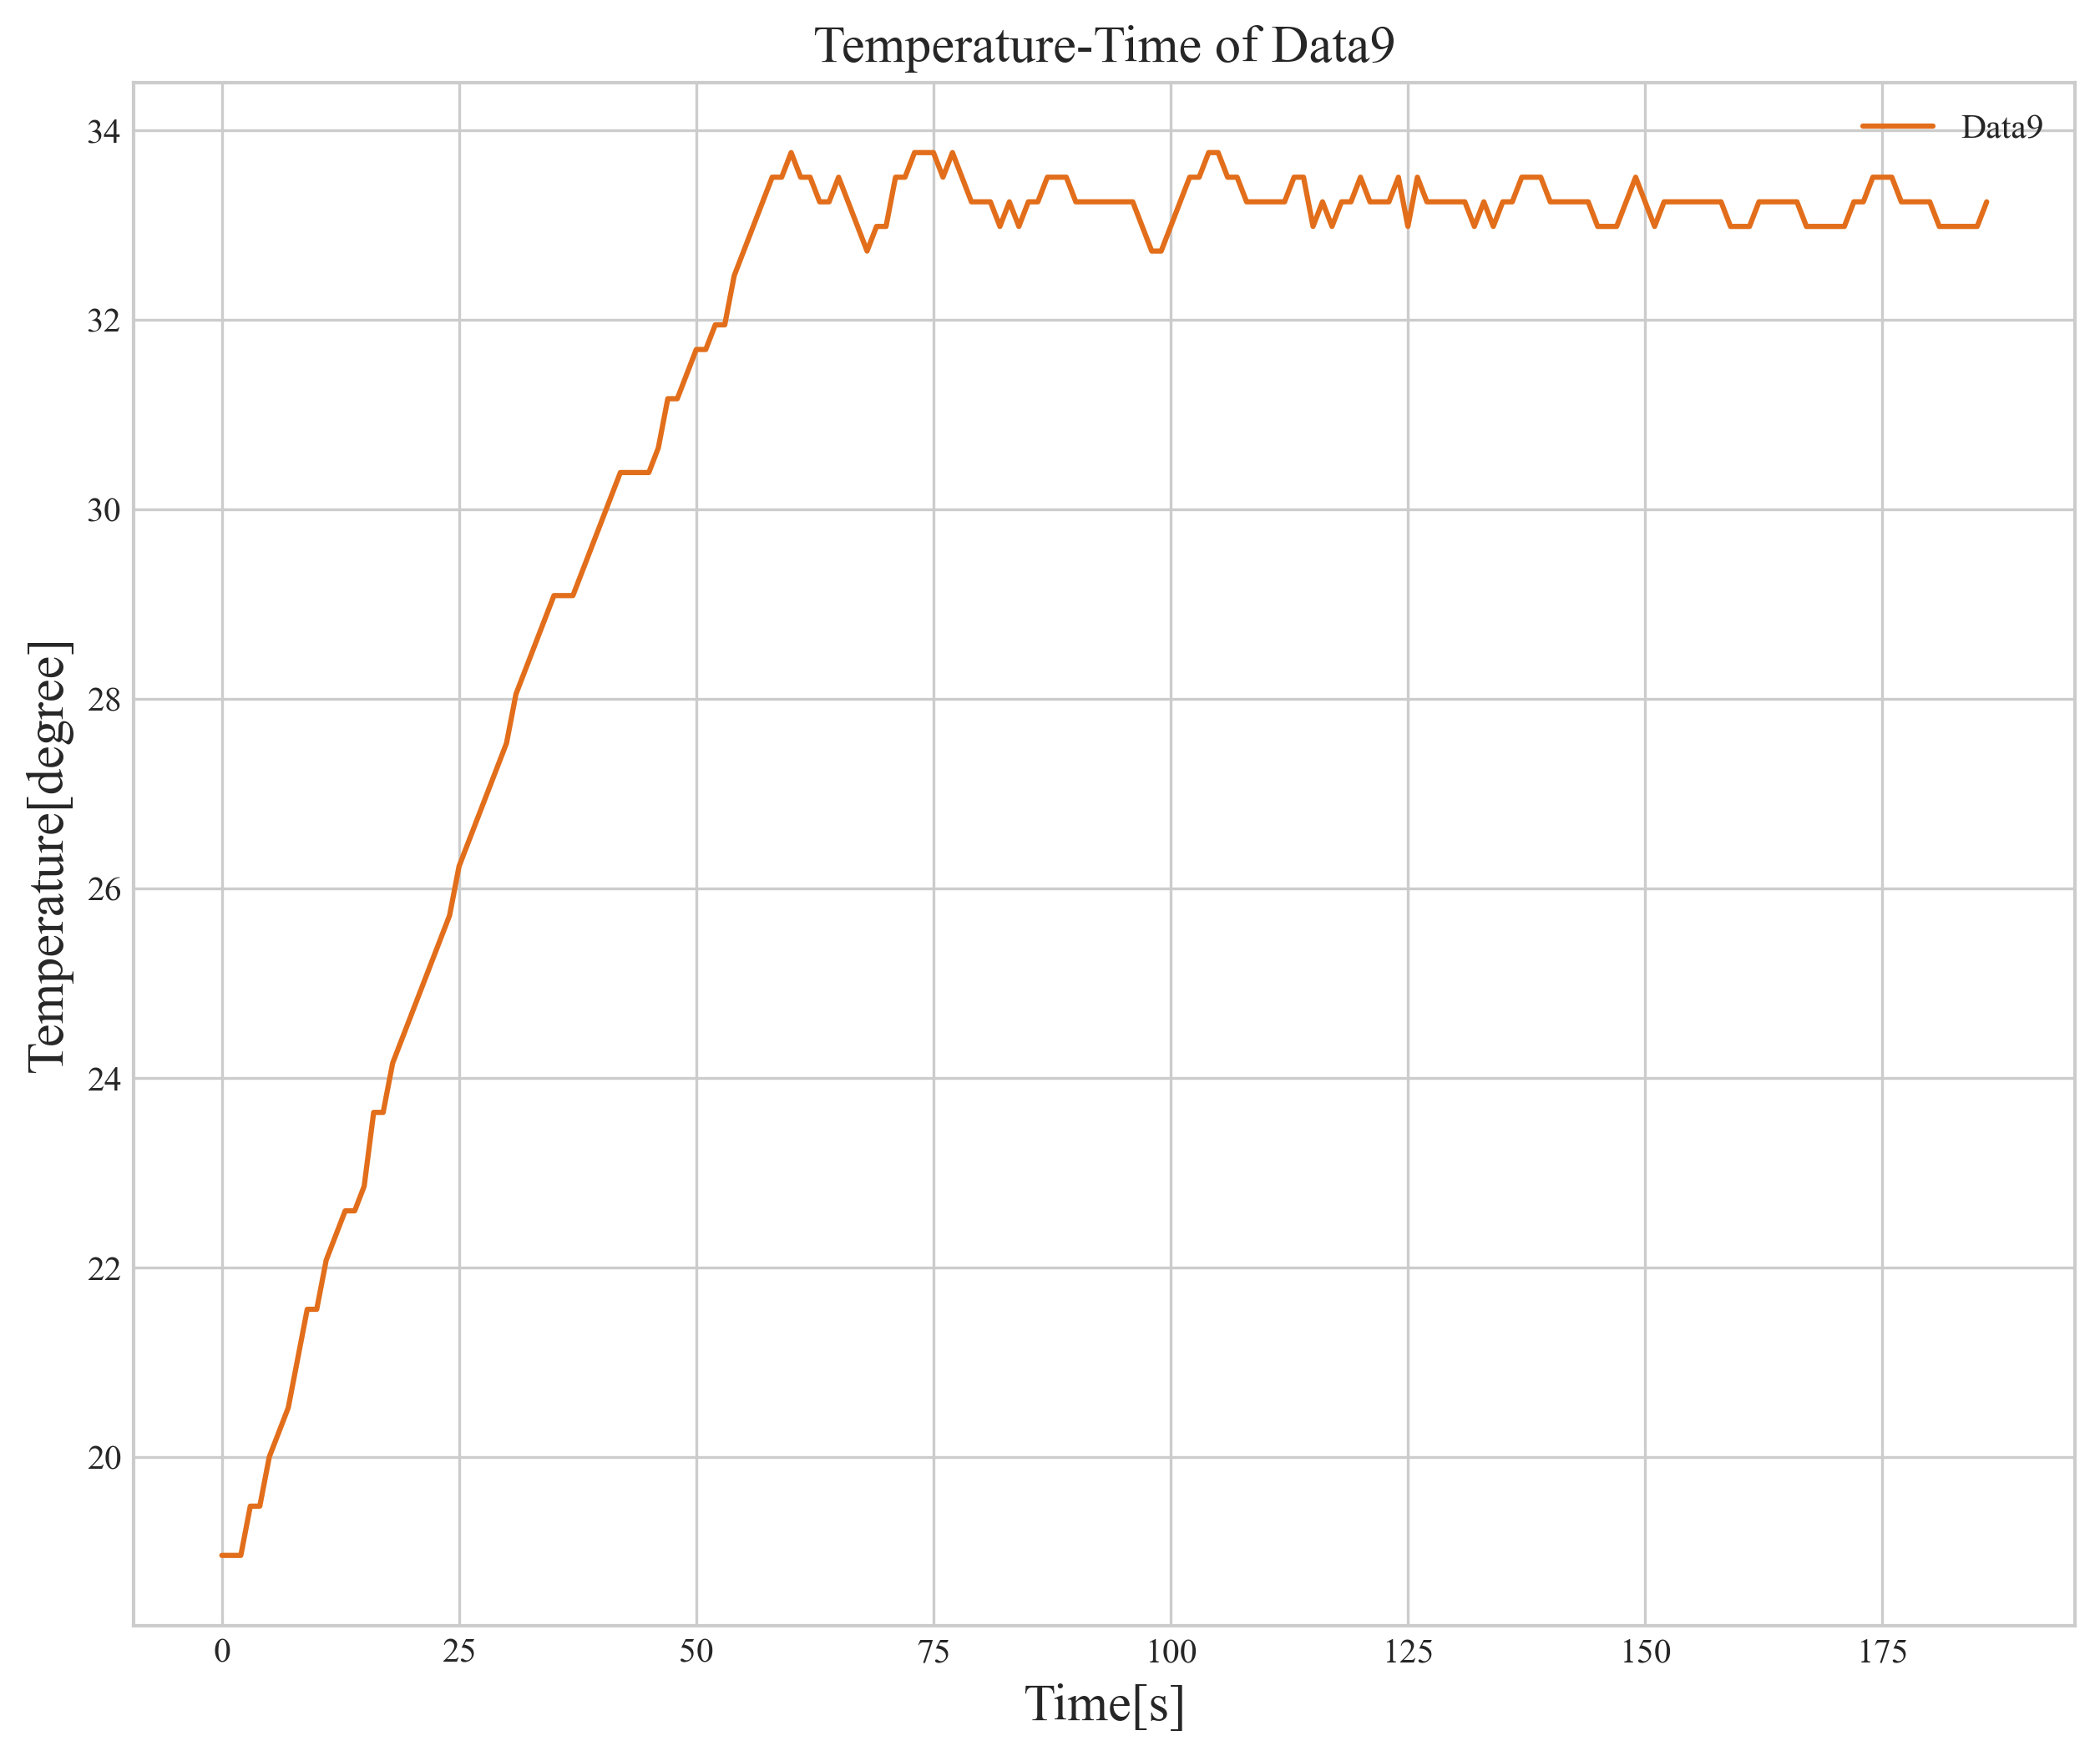

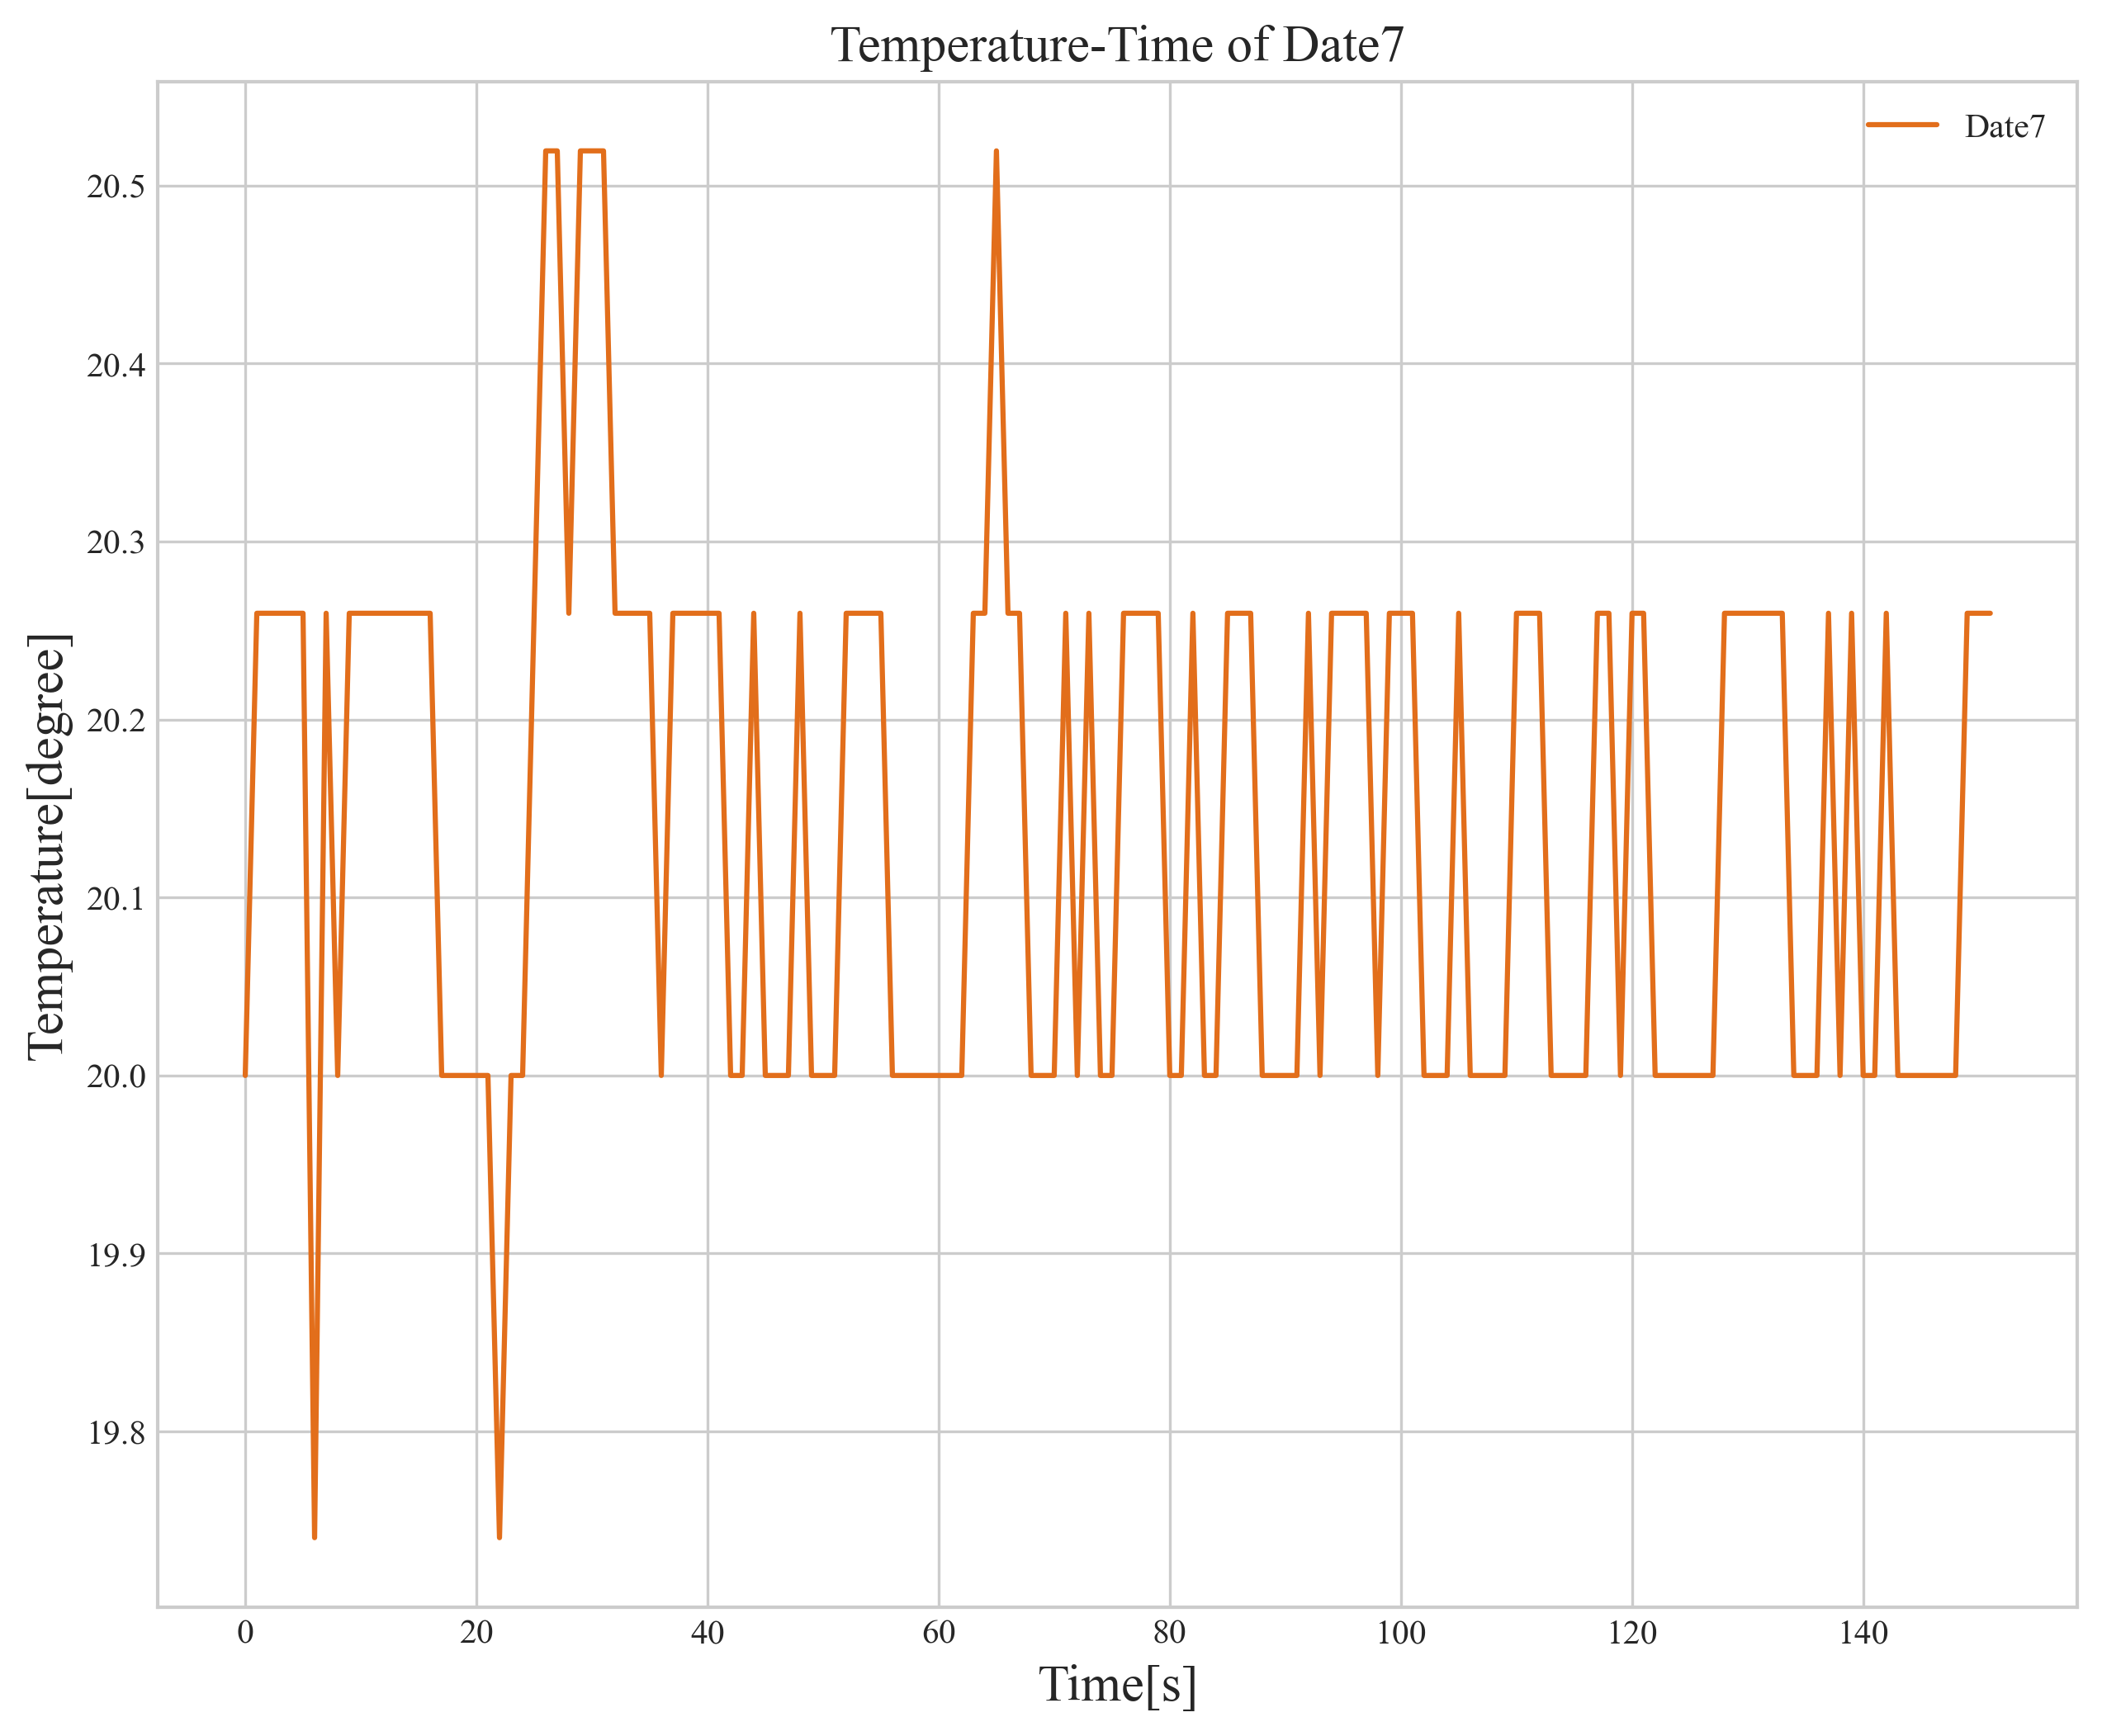

In [2]:
import glob

# 文件夹路径
folder_path = 'D:/JupyterNotebooks/Lab2/Lab2_9'

# 获取文件夹中所有Excel文件的路径
excel_files = glob.glob(f'{folder_path}/*.xlsx')

# 遍历每个Excel文件，读取数据并绘制时序图
for file_path in excel_files:
    # 读取Excel文件
    df = pd.read_excel(file_path)

    # 假设时间列名为 'Time'，温度列名为 'Temperature'
    time = df['时间 - 曲线 0']
    temperature = df['幅值 - 曲线 0']

    # 从文件路径中提取文件名作为图表标题的一部分
    file_name = file_path.split('/')[-1]
    name = file_name[13:18]

    # 绘制时序图
    plt.figure()
    plt.plot(time, temperature, linestyle='-', label=name, color='#e26e1b')
    plt.title('Temperature-Time of '+name)
    plt.xlabel('Time[s]')
    plt.ylabel('Temperature[degree]')
    plt.legend()
    plt.grid(True)
    plt.show()

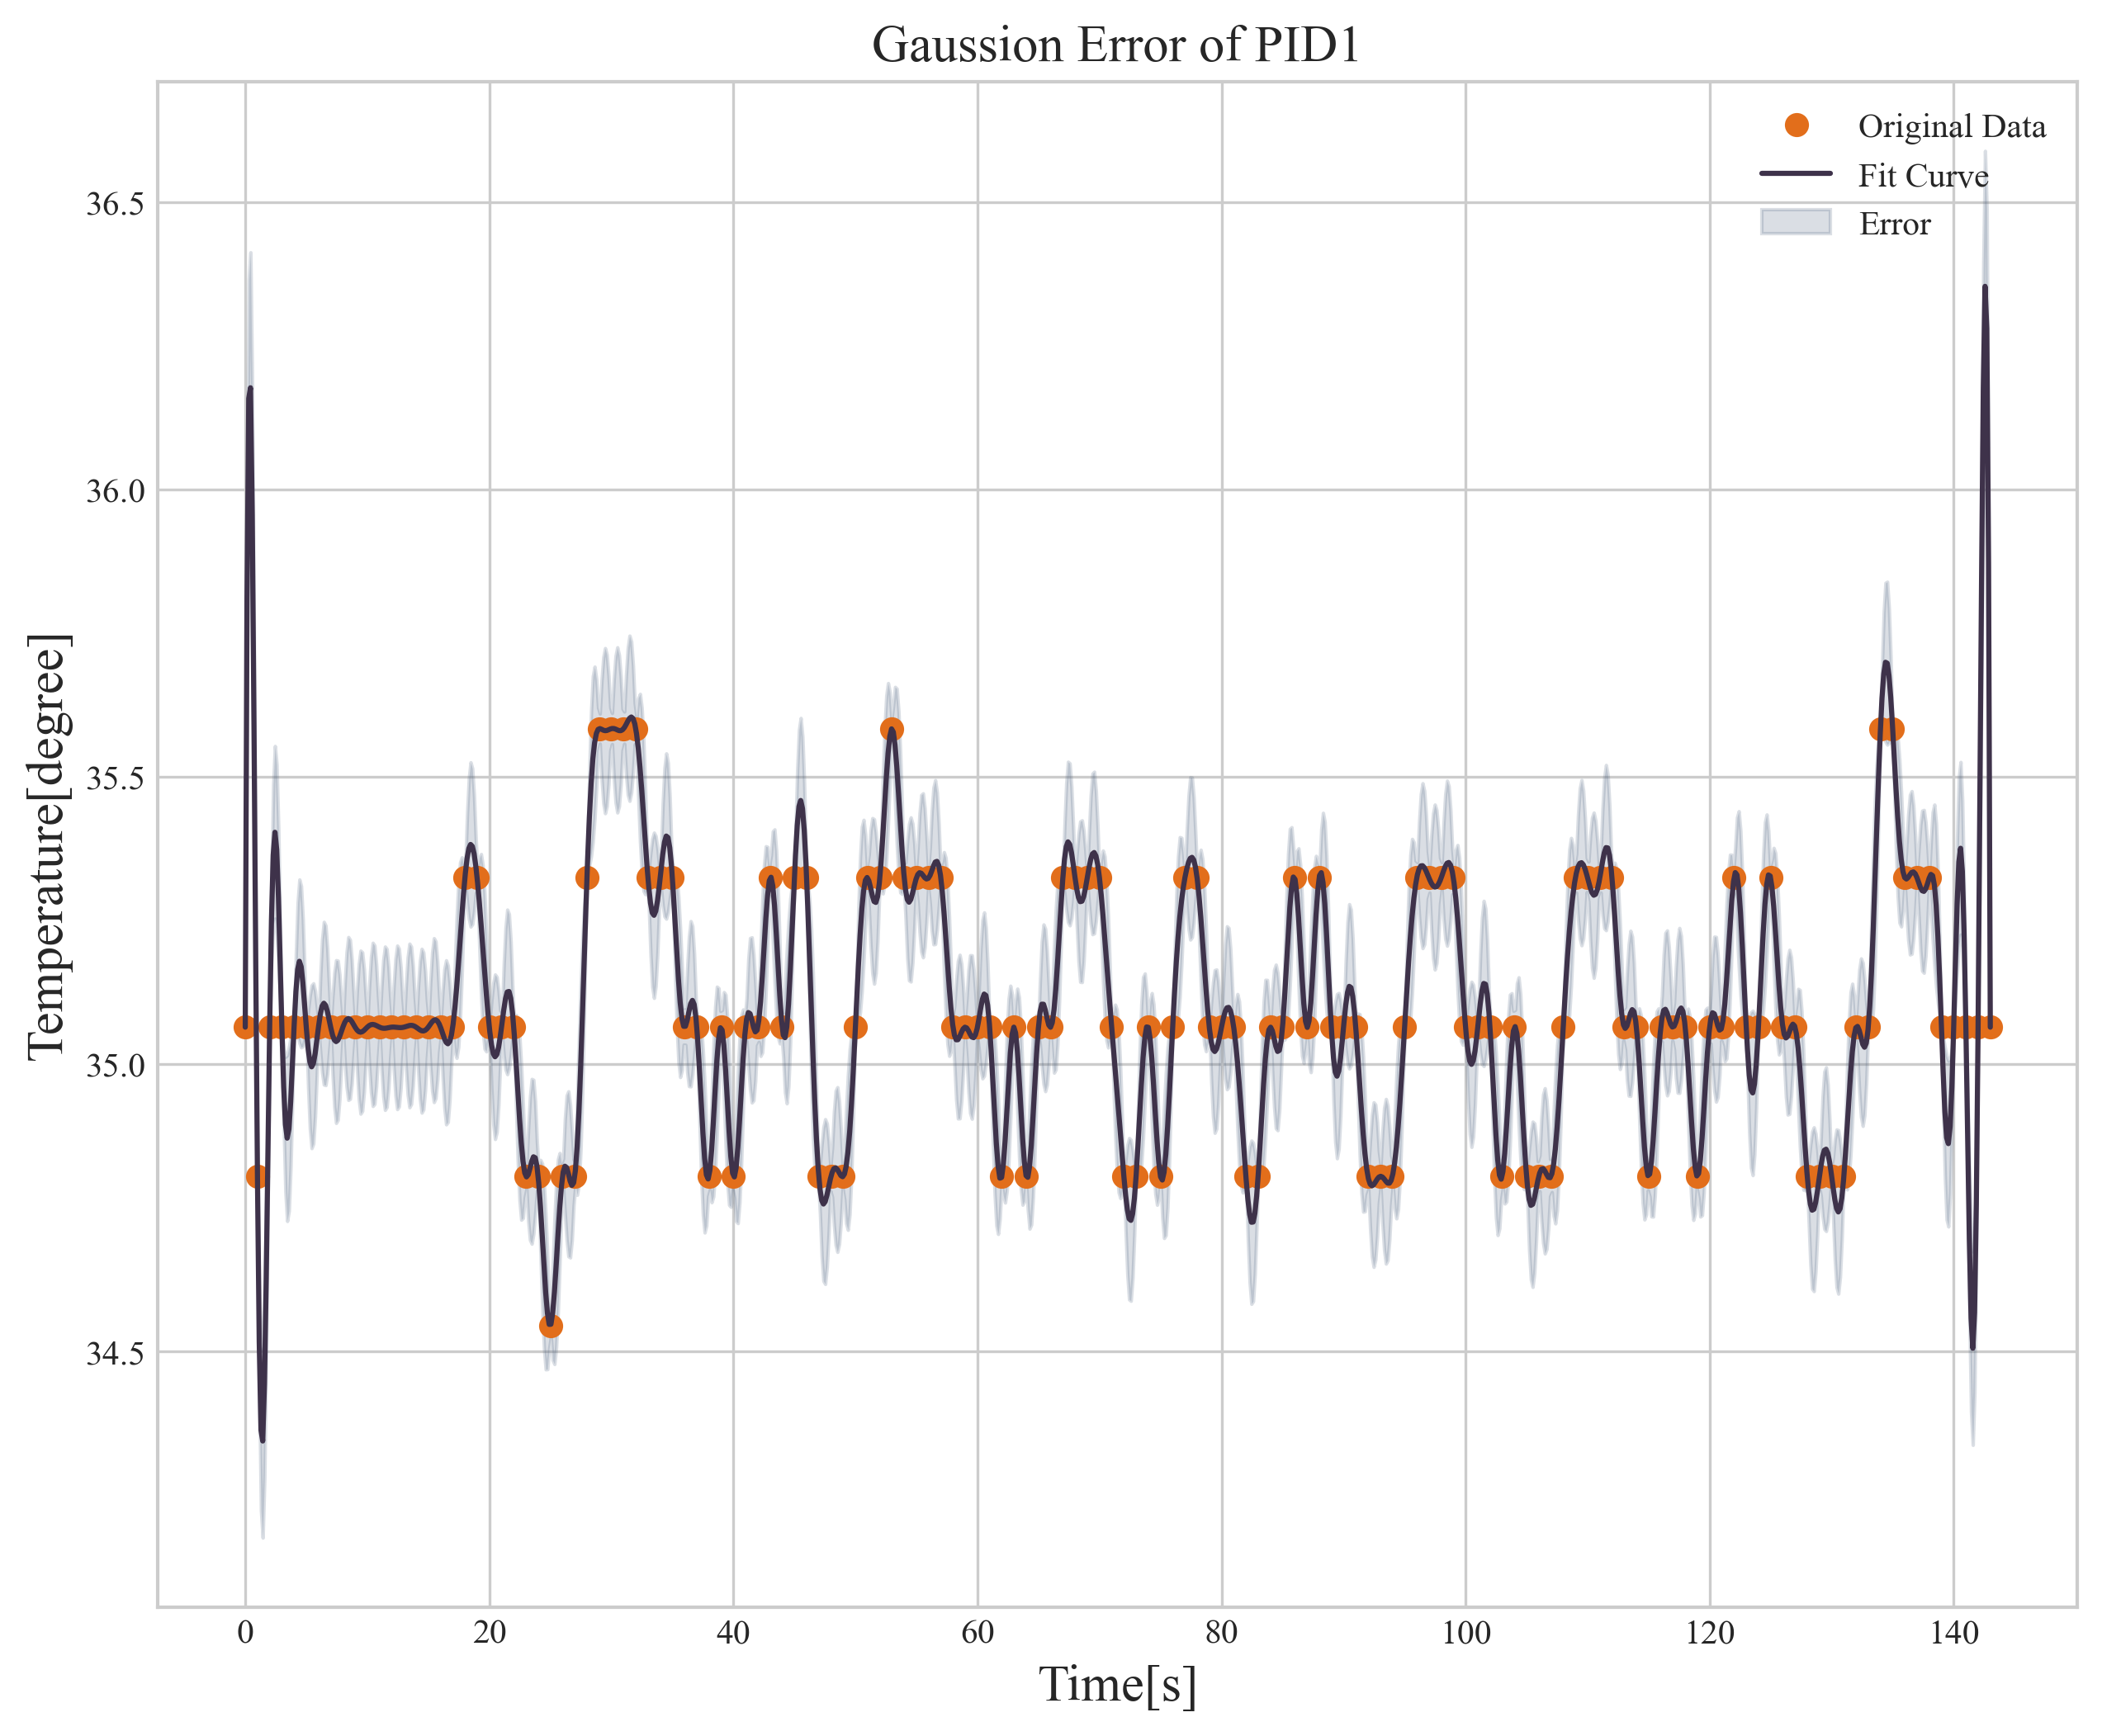

In [3]:
# 尝试作连续曲线的误差分析

df1 = pd.read_excel('Lab2_9Data4_PID.xlsx')
x1 = np.array(df1['时间 - 曲线 0'])
y1 = np.array(df1['幅值 - 曲线 0'])

from sklearn.gaussian_process import GaussianProcessRegressor

# 计算高斯过程回归，使其符合 fit 数据点
gp = GaussianProcessRegressor()
gp.fit(x1[:, np.newaxis], y1)

xfit = np.linspace(0, max(x1), 1000)
yfit, std = gp.predict(xfit[:, np.newaxis], return_std=True)
dyfit = 2 * std  # 两倍sigma: 95%确定区域

# 可视化结果
plt.figure()
plt.plot(x1, y1, 'o', color='#e26e1b',label='Original Data')
plt.plot(xfit, yfit, '-', color='#3e324a', label='Fit Curve')

plt.fill_between(xfit, yfit - dyfit, yfit + dyfit,
                 color='#475d7b', alpha=0.2, label='Error') 
plt.title('Gaussion Error of PID1')
plt.xlabel('Time[s]')
plt.ylabel('Temperature[degree]')
plt.legend()
plt.grid(True)
plt.show()

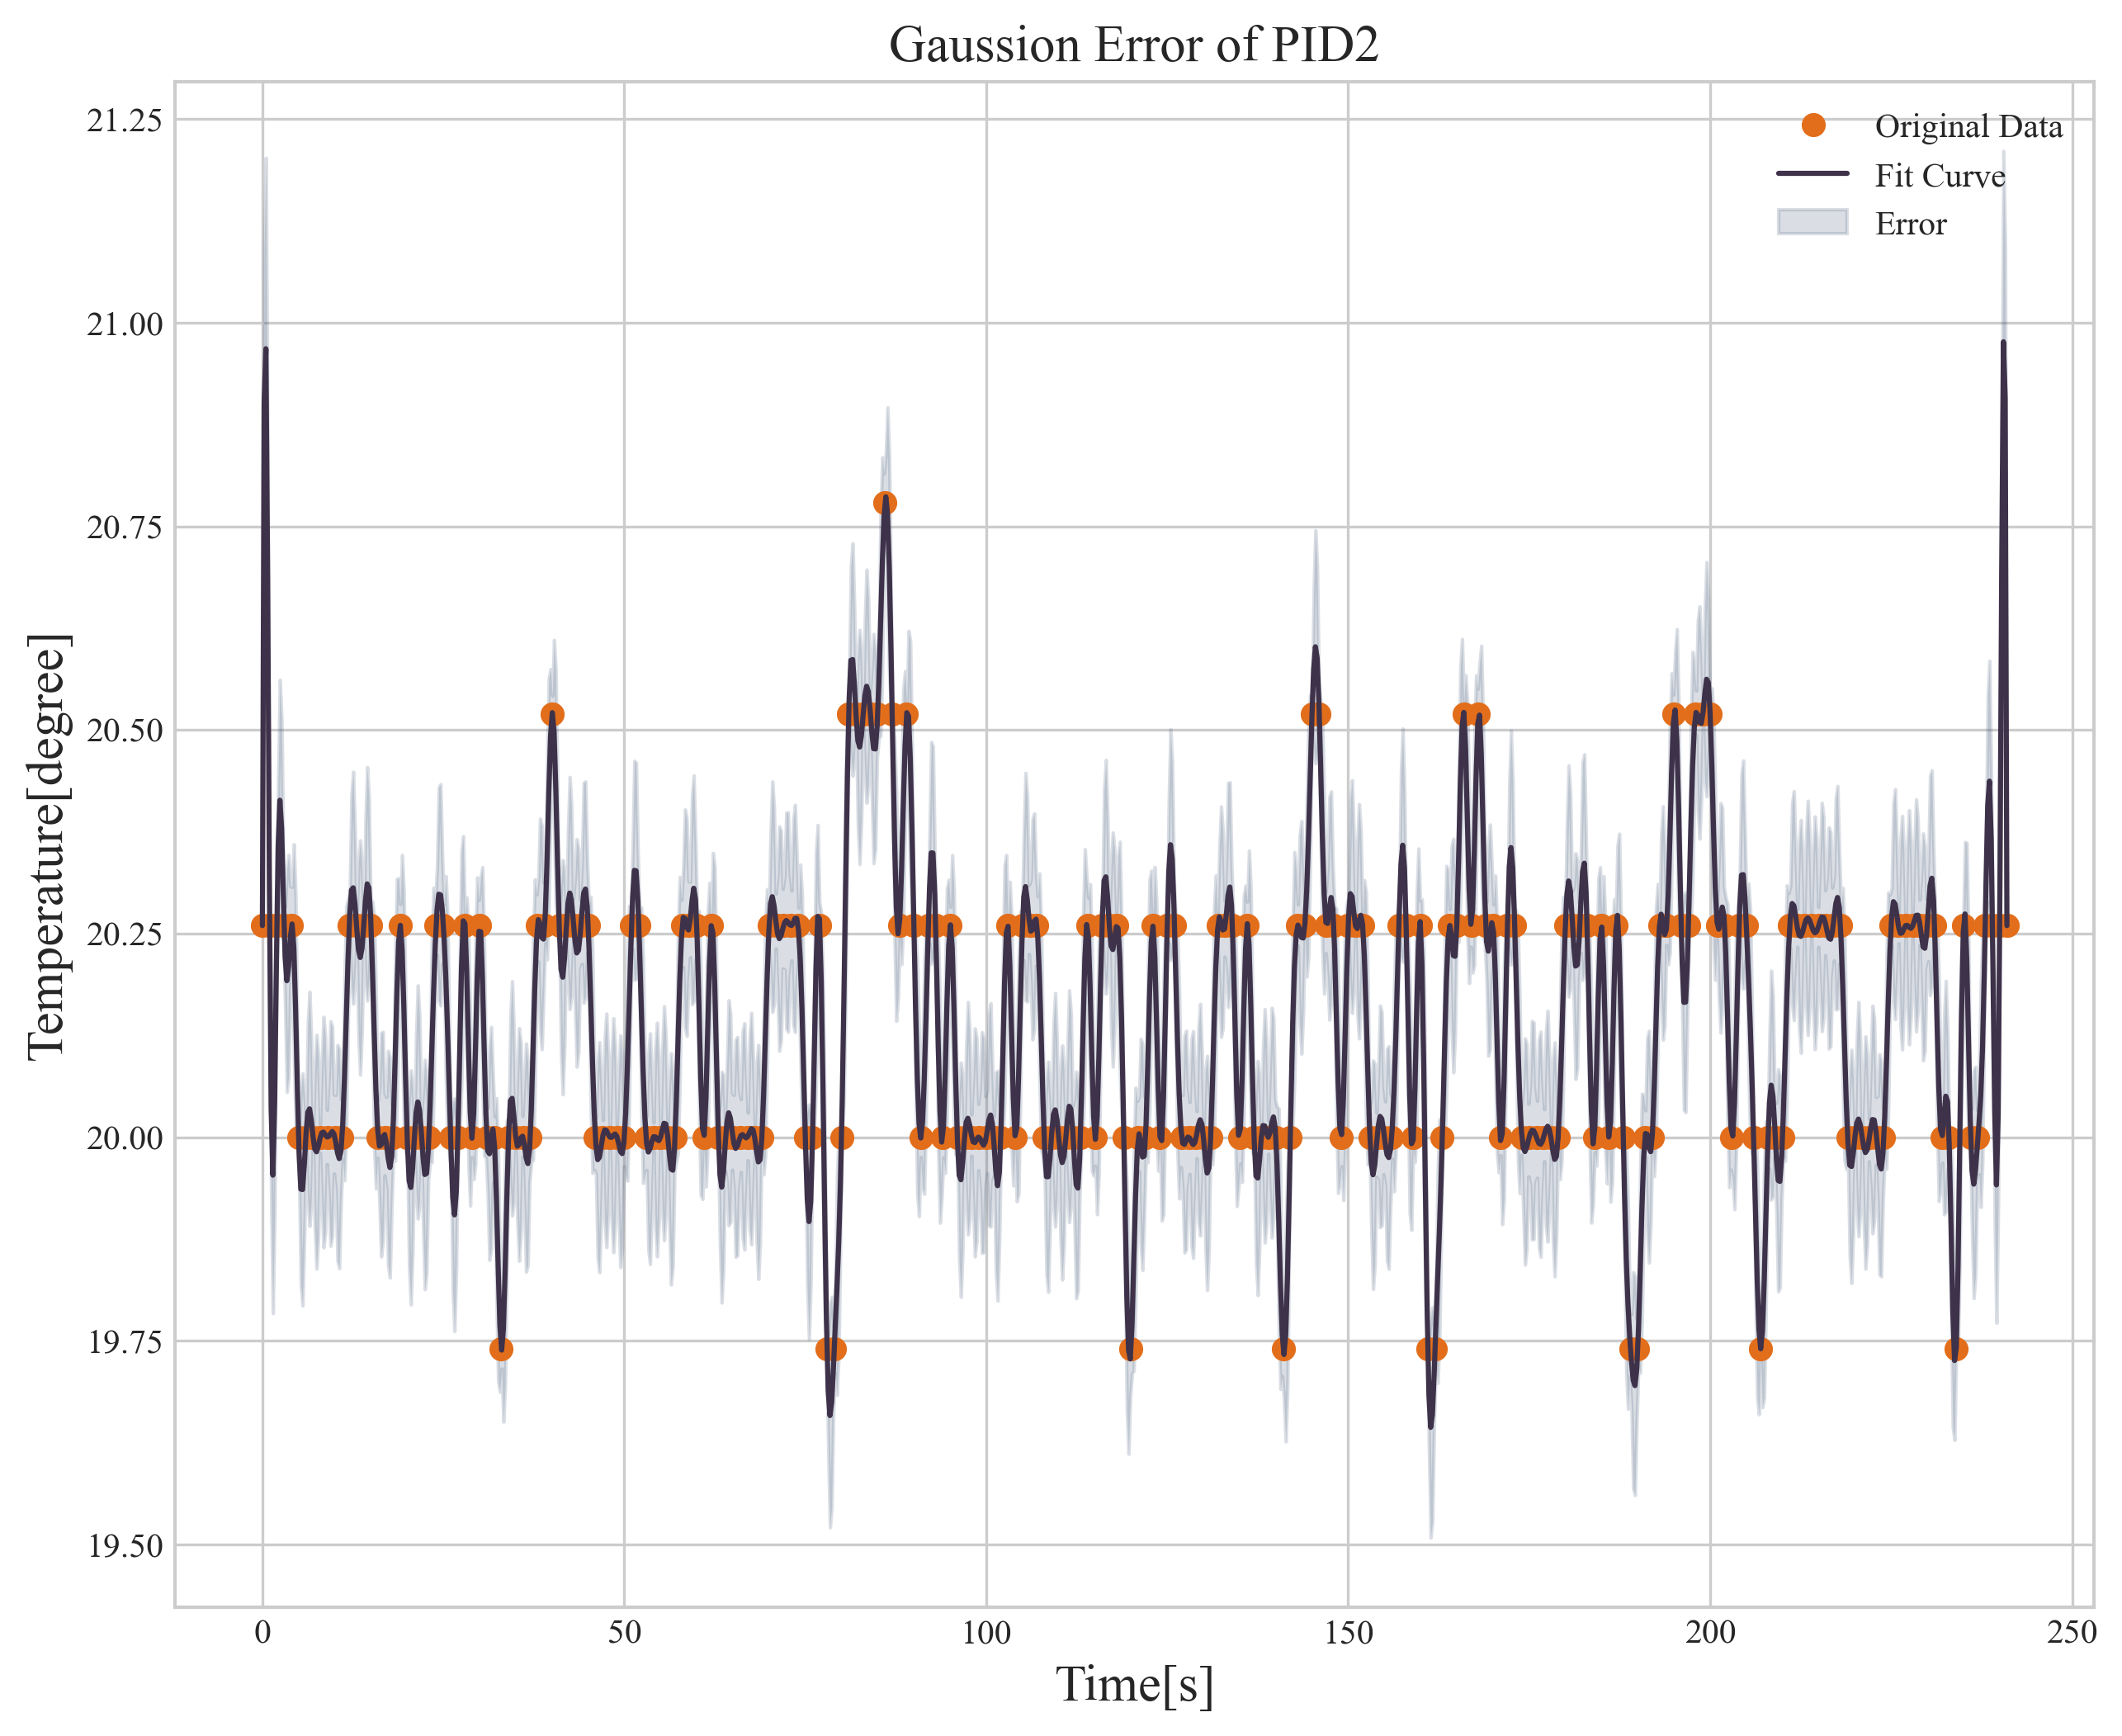

In [4]:
df2 = pd.read_excel('Lab2_9Data8_20PID.xlsx')
x2 = np.array(df2['时间 - 曲线 0'])
y2 = np.array(df2['幅值 - 曲线 0'])

from sklearn.gaussian_process import GaussianProcessRegressor

# 计算高斯过程回归，使其符合 fit 数据点
gp = GaussianProcessRegressor()
gp.fit(x2[:, np.newaxis], y2)

xfit2 = np.linspace(0, max(x2), 1000)
yfit2, std2 = gp.predict(xfit2[:, np.newaxis], return_std=True)
dyfit2 = 2 * std2  # 两倍sigma: 95%确定区域

# 可视化结果
plt.figure()
plt.plot(x2, y2, 'o', color='#e26e1b',label='Original Data')
plt.plot(xfit2, yfit2, '-', color='#3e324a', label='Fit Curve')

plt.fill_between(xfit2, yfit2 - dyfit2, yfit2 + dyfit2,
                 color='#475d7b', alpha=0.2, label='Error') 
plt.title('Gaussion Error of PID2')
plt.xlabel('Time[s]')
plt.ylabel('Temperature[degree]')
plt.legend()
plt.grid(True)
plt.show()

D:\5\5_V1\lib\site-packages\scipy\signal\_spectral_py.py:1999: UserWarning: nperseg = 256 is greater than input length  = 242, using nperseg = 242
  warnings.warn('nperseg = {0:d} is greater than input length '


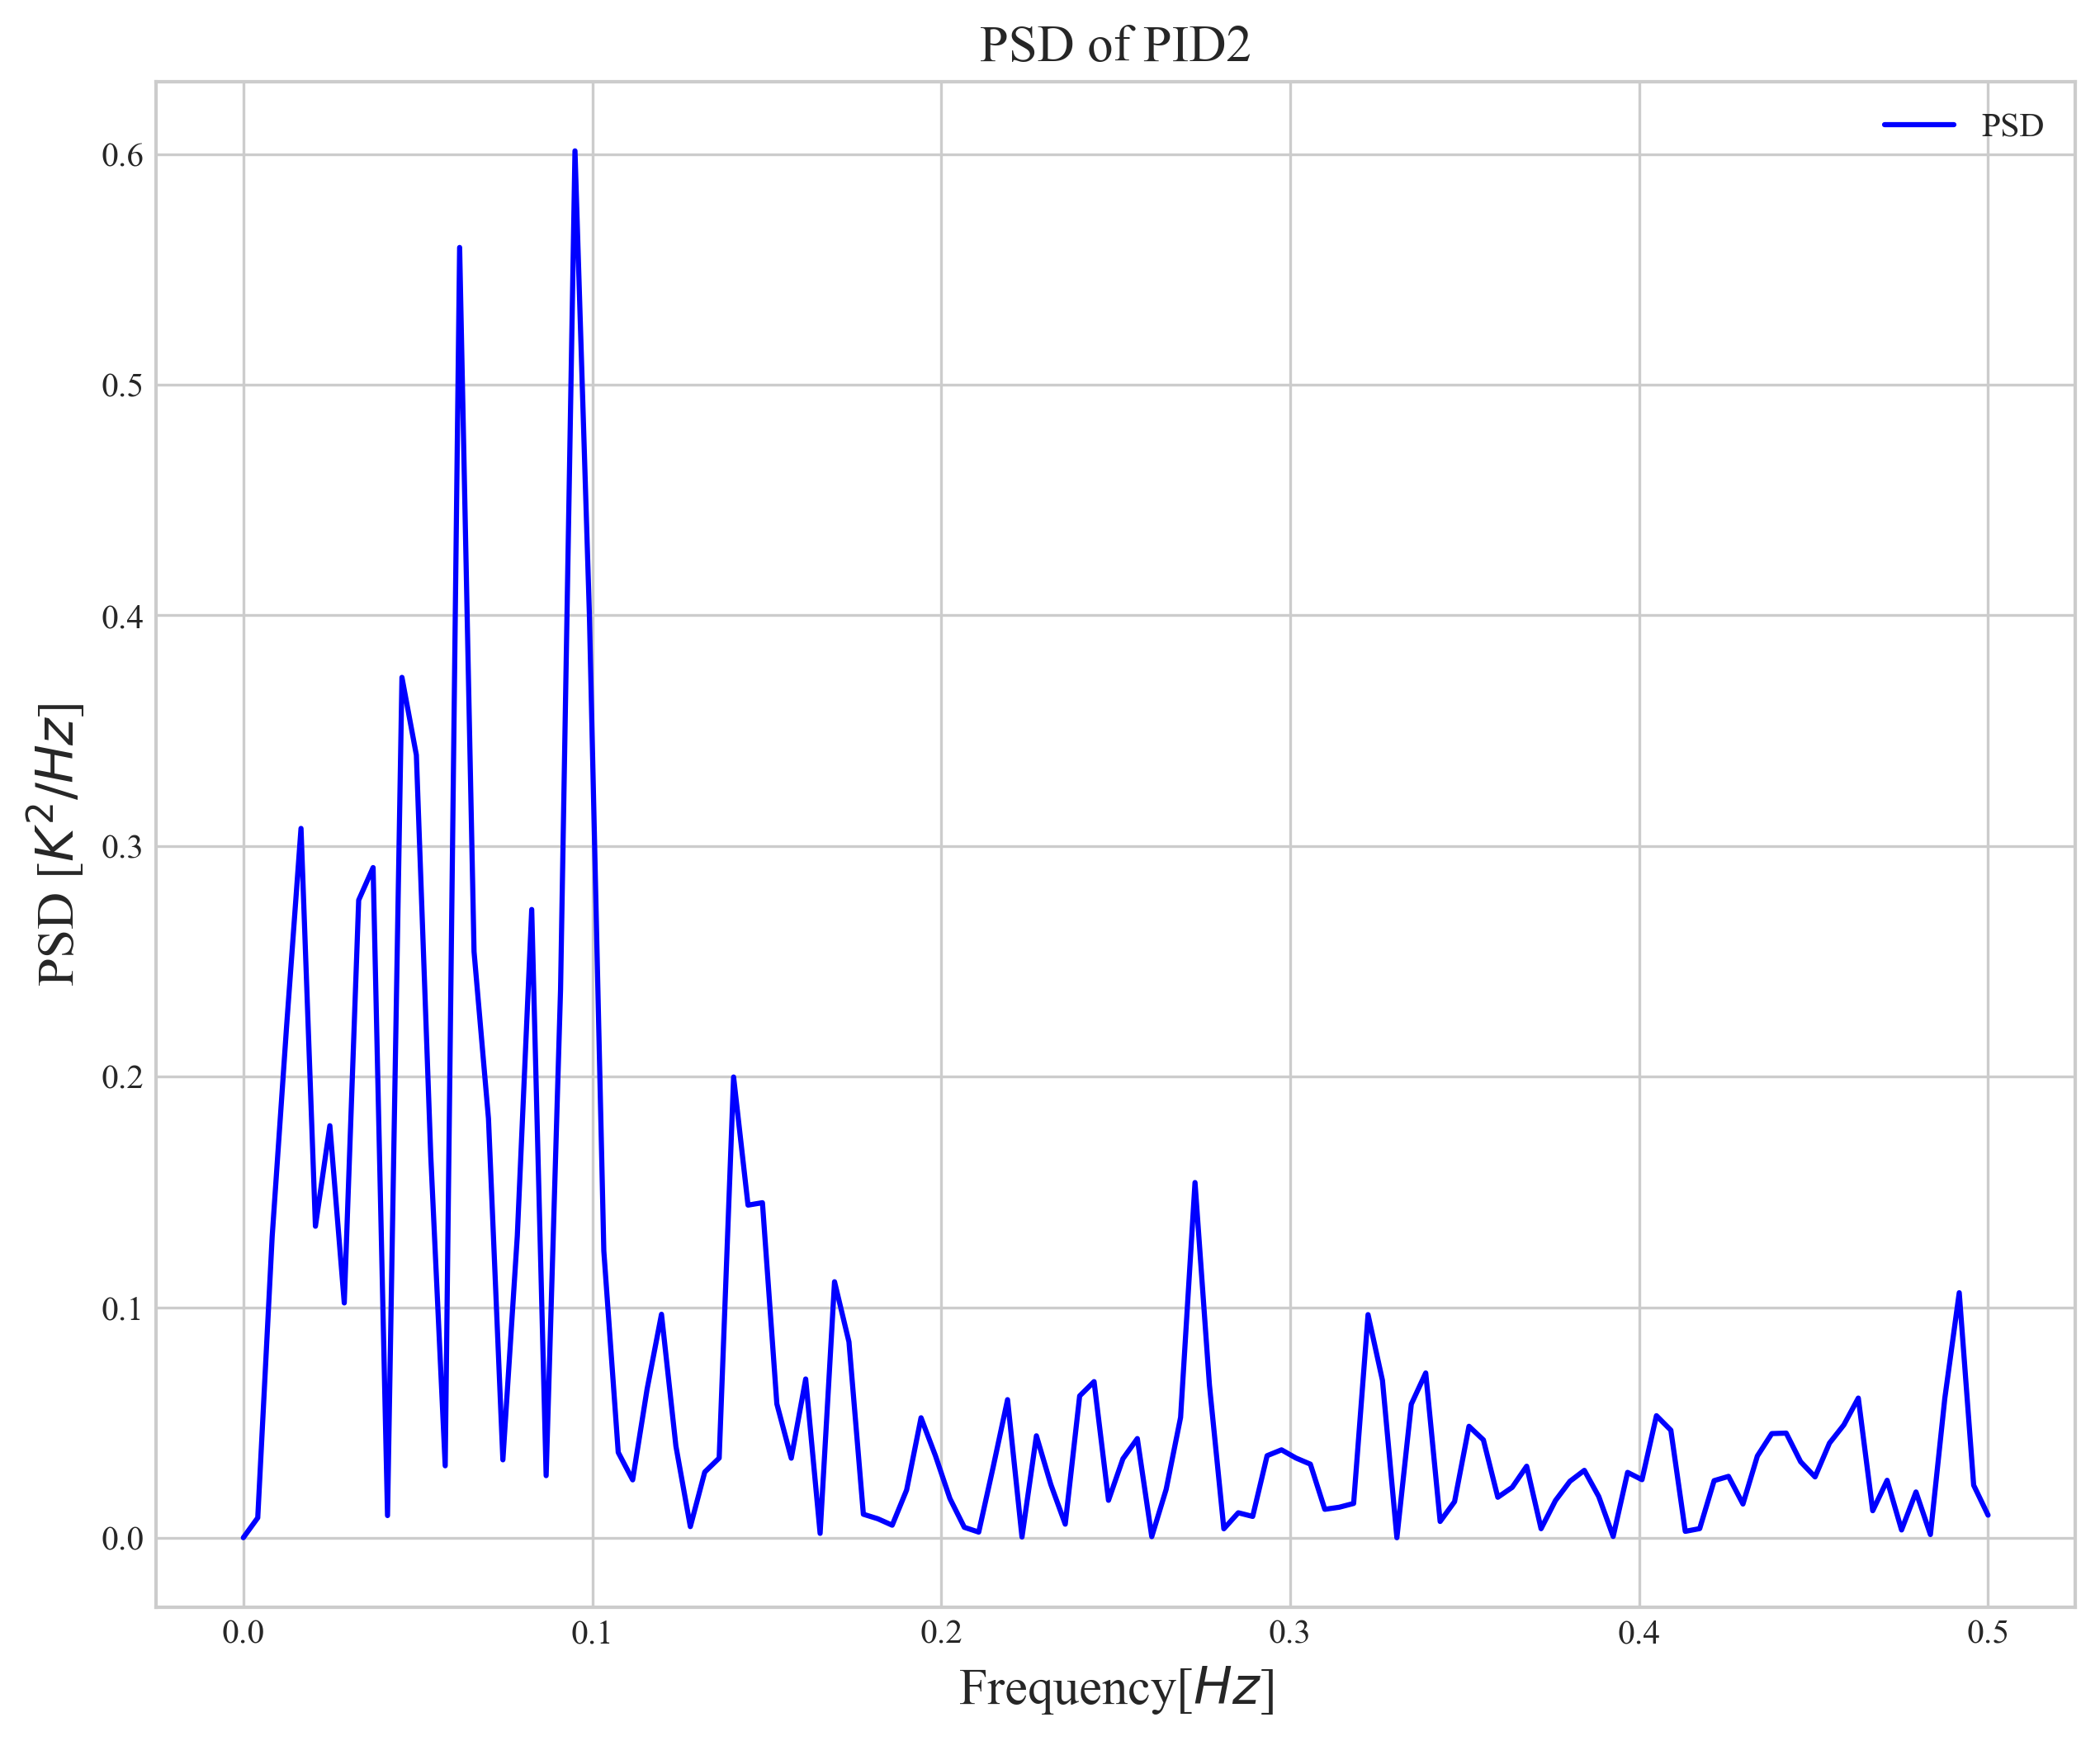

In [12]:
from scipy.signal import welch

# 读取Excel文件中的数据
file_path = 'Lab2_9Data8_20PID.xlsx'  # 请将此路径替换为你的Excel文件路径

# 使用pandas读取Excel文件
data = pd.read_excel(file_path)

# 假设你的数据有两列，分别是时间和温度
time = data['时间 - 曲线 0']
temperature = data['幅值 - 曲线 0'] + 273.15

# 计算采样频率
#dt = np.mean(np.diff(time))
#fs = 1 / dt

# 计算PSD
frequencies, psd = welch(temperature)

# 计算ASD
asd = np.sqrt(psd)

# 可视化结果
plt.figure()
plt.plot(frequencies, psd, label='PSD', color='blue')
plt.title('PSD of PID2')
plt.xlabel('Frequency[$Hz$]')
plt.ylabel('PSD [$K^2/Hz$]')
plt.legend()
plt.grid(True)
plt.show()